# Pre-procesamiento

## Importación de paquetes

In [1]:
import pandas as pd
import numpy as np
import math, shap
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, ParameterGrid, KFold, GridSearchCV, PredefinedSplit
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, roc_auc_score, make_scorer, r2_score, confusion_matrix, classification_report, precision_score, recall_score, accuracy_score
from sklearn.datasets import make_classification
from sklearn.neural_network import BernoulliRBM
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from minisom import MiniSom
from feature_selector import FeatureSelector
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn import tree

c:\Users\poshiro\Documents\tfm\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Importación de datos

In [2]:
data_dir = Path("data/validaciones")
csv_files = sorted(data_dir.glob("*.csv"))

dfs = []
for csv_path in csv_files:
    df_temp = pd.read_csv(csv_path)
    if 'Conductor' in df_temp.columns:
        df_temp['Conductor'] = df_temp['Conductor'].str.replace(r'^#\s*', '', regex=True)
        df_temp['Conductor'] = df_temp['Conductor'].str.strip()
    dfs.append(df_temp)

if dfs:
    df_validaciones = pd.concat(dfs, ignore_index=True)
else:
    df_validaciones = pd.DataFrame()

print(f"Cargados {len(csv_files)} archivos y {len(df_validaciones)} filas en el DataFrame")

df_validaciones.head()

Cargados 24 archivos y 8067804 filas en el DataFrame


,Tipus validació,Bus,Conductor,Data validació,Hora validació,Línia,Ruta,Viatge,Parada,Tipus targeta,Bitllet/Recàrrega,RFID/Codi extern,Data venda,Hora venda,Preu,Moneda,Proveïdor,Consum,Crèdits consumits
0,Ticket,M5170,269,2025/04/01,00:01:52,NaN,NaN,NaN,NaN,Recarregable,Abonament mensual,FB910B26,2025/03/29,00:16:28,30.0,EUR,Venda COOPALSA,Z4,NaN
1,NIA,M5170,269,2025/04/01,00:01:57,NaN,NaN,NaN,NaN,Targeta Resident,NaN,542005B0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NIA,M7316,273,2025/04/01,00:01:59,NaN,NaN,NaN,NaN,Targeta Resident,NaN,19C0F575,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NIA,M7316,273,2025/04/01,00:02:01,NaN,NaN,NaN,NaN,Targeta Resident,NaN,07E5623A,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NIA,M7316,273,2025/04/01,00:03:24,NaN,NaN,NaN,NaN,Targeta Resident,NaN,18771E91,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Agregación de datos

In [3]:
columns_to_check = ['Línia', 'Ruta', 'Viatge', 'Parada']
for col in columns_to_check:
    if col in df_validaciones.columns:
        print(f"{col}: {df_validaciones[col].isna().sum()} NaN")

Línia: 2692063 NaN
Ruta: 2692063 NaN
Viatge: 2692063 NaN
Parada: 2692063 NaN


In [4]:
df_validaciones.drop(columns=['Bus', 'Conductor', 'Preu', 'Crèdits consumits', 'Bitllet/Recàrrega', 'Data venda', 'Hora venda', 'Moneda', 'Proveïdor', 'Consum'], inplace=True)

Nos quedamos solo con los viajes susceptibles de ser fraude

In [5]:
df_validaciones_residents = df_validaciones[df_validaciones['Tipus targeta']=='Targeta Resident']
df_validaciones_residents.drop(columns=['Tipus targeta'], inplace=True)

Añadimos la información de las paradas al dataset

In [6]:
paradas_path = Path("data/parades_andorra.csv")
df_paradas = pd.read_csv(paradas_path)
print(f"Cargadas {len(df_paradas)} filas de {paradas_path.name}")
df_paradas = df_paradas.rename(columns={"Codi": "codi", "Nom": "Parada"})
df_paradas.head()

Cargadas 403 filas de parades_andorra.csv


,codi,Parada,latitude,longitude,description,vocalLanguage,city,url,radius,wheelchairBoarding,Codi 1,Codi 2,timezone
0,182,Bordes d'Envalira,42.560111,1.685056,NaN,ca,les Bordes d'Envalira,NaN,undefined,0,NaN,NaN,Europe/Andorra
1,172,Soldeu,42.577000,1.666417,NaN,ca,Soldeu,NaN,undefined,0,NaN,NaN,Europe/Andorra
2,166,Roc de Sant Miquel,42.580250,1.664056,NaN,ca,Soldeu,NaN,undefined,0,NaN,NaN,Europe/Andorra
3,164,Vall d'Incles II,42.583901,1.663429,NaN,ca,Sant Pere,NaN,undefined,0,NaN,NaN,Europe/Andorra
4,162,Moles,42.579806,1.659278,NaN,ca,Sant Pere,NaN,undefined,0,NaN,NaN,Europe/Andorra


In [7]:
# 1. Agrupar df_paradas por 'Parada' y calcular la media de latitud y longitud
df_paradas_medias = df_paradas.groupby('Parada', as_index=False).agg({
    'latitude': 'mean',
    'longitude': 'mean'
})

df_val_par = pd.merge(df_validaciones_residents, df_paradas_medias, on='Parada', how='left')

Por la manera en que están planteadas las zonas, se crean tantas validaciones como zonas consumidas, por lo que debemos borrar las duplicadas para que no interfieran en el entrenamiento.

In [8]:
df_val_par.drop_duplicates(subset=['Data validació', 'Hora validació', 'RFID/Codi extern', 'Línia', 'Ruta', 'Viatge', 'Parada', 'latitude', 'longitude'], keep='first', inplace=True)

## Imputación de nulos

In [9]:
df = df_val_par.copy()

# ==========================================
# 1. Definir las columnas a imputar
# ==========================================
# Columnas con valores geográficos (numéricos)
cols_geo = ['latitude', 'longitude']

# Columnas categóricas (strings o enteros) que identifican el viaje/parada
cols_cat = ['Ruta', 'Línia', 'Viatge', 'Parada']

# Todas las columnas a imputar
cols_a_imputar = cols_geo + cols_cat

# ==========================================
# 2. Crear la bandera ANTES de imputar (True si falta ALGUNA de estas columnas)
# ==========================================
df['coord_imputada'] = df[cols_geo].isna().any(axis=1) | df[cols_cat].isna().any(axis=1)

# ==========================================
# 3. Para variables categóricas: creamos una columna combinada que concatene TODAS
#    las columnas categóricas en un solo string, para poder sacar la moda conjunta.
#    Pero cuidado: cada columna debe imputarse independientemente.
#    Estrategia: agrupar por RFID y calcular la moda de CADA columna por separado.
# ==========================================

# --- 3a. Calcular moda para cada columna categórica ---
# Esto lo hacemos con un diccionario de agregación
modas_por_usuario = df.dropna(subset=cols_a_imputar).groupby('RFID/Codi extern').agg(
    # Para columnas geo, la moda (aunque también podríamos usar media, pero aquí usamos moda)
    **{f'moda_{col}': (col, lambda x: x.mode().iloc[0] if not x.mode().empty else None) 
       for col in cols_a_imputar}
).reset_index()

# ==========================================
# 4. Unir las modas al DataFrame original
# ==========================================
df = df.merge(modas_por_usuario, on='RFID/Codi extern', how='left')

# ==========================================
# 5. Imputar SOLO donde falta cada columna
# ==========================================
for col in cols_a_imputar:
    moda_col = f'moda_{col}'
    mask_falta = df[col].isna()
    df.loc[mask_falta, col] = df.loc[mask_falta, moda_col]
    # (Opcional) Si quedan NaN (porque el usuario no tenía moda en esa columna), se mantienen.

# ==========================================
# 6. (Opcional) Si algún usuario no tiene moda en alguna columna (porque no tenía ni un dato),
#    podemos rellenar con la moda global de esa columna.
# ==========================================
for col in cols_a_imputar:
    # Si aún hay NaN en alguna columna, los rellenamos con la moda global (de todos los usuarios)
    if df[col].isna().any():
        moda_global = df[col].mode().iloc[0] if not df[col].mode().empty else None
        if moda_global is not None:
            df[col] = df[col].fillna(moda_global)
            print(f"Rellenados con moda global en {col}: {df[col].isna().sum()} NaN restantes")

# ==========================================
# 7. Limpiar columnas temporales (las que empiezan por 'moda_')
# ==========================================
cols_moda = [f'moda_{col}' for col in cols_a_imputar]
df = df.drop(columns=cols_moda)

# ==========================================
# 8. Resumen final
# ==========================================
print("="*50)
print("RESUMEN DE IMPUTACIÓN POR USUARIO (MODA)")
print("="*50)
total_filas = len(df)
total_imputadas = df['coord_imputada'].sum()
print(f"Total filas: {total_filas}")
print(f"Filas con al menos una columna imputada: {total_imputadas} ({total_imputadas/total_filas*100:.1f}%)")
for col in cols_a_imputar:
    nulos = df[col].isna().sum()
    print(f"  {col}: {nulos} NaN restantes (imputados si había moda)")
print("="*50)

Rellenados con moda global en latitude: 0 NaN restantes
Rellenados con moda global en longitude: 0 NaN restantes
Rellenados con moda global en Ruta: 0 NaN restantes
Rellenados con moda global en Línia: 0 NaN restantes
Rellenados con moda global en Viatge: 0 NaN restantes
Rellenados con moda global en Parada: 0 NaN restantes
RESUMEN DE IMPUTACIÓN POR USUARIO (MODA)
Total filas: 5796876
Filas con al menos una columna imputada: 1888014 (32.6%)
  latitude: 0 NaN restantes (imputados si había moda)
  longitude: 0 NaN restantes (imputados si había moda)
  Ruta: 0 NaN restantes (imputados si había moda)
  Línia: 0 NaN restantes (imputados si había moda)
  Viatge: 0 NaN restantes (imputados si había moda)
  Parada: 0 NaN restantes (imputados si había moda)


In [10]:
df_val_par = df

## Encoding

In [11]:
# Codificación de categorías por frecuencia
categorical_cols = ['Tipus validació', 'Ruta', 'Línia', 'Viatge', 'Parada']

for col in categorical_cols:
    freq_map = df_val_par[col].value_counts(normalize=False)  # Conteo absoluto
    df_val_par[f'{col}_freq'] = df_val_par[col].map(freq_map)
    # Eliminar la columna original categórica (ya no la necesitamos)
    df_val_par.drop(columns=[col], inplace=True)


In [12]:
# Codificación de usuario
le = LabelEncoder()
df_val_par['rfid'] = le.fit_transform(df_val_par['RFID/Codi extern'])
df_val_par.drop(columns=['RFID/Codi extern'], inplace=True)

## Paleta de colores

In [13]:
graph_palette = ["#1E88E5", "#FF0d57", "#13B755", "#7C52FF", "#FFC000", "#00AEEF"]
graph_cmap = LinearSegmentedColormap.from_list("shap_gradient", [graph_palette[0], graph_palette[1]])

## Enriquecemos el dataset con datos derivados

### Tiempo

In [14]:
# 3. convertir fecha y hora
df_val_par['Data validació'] = pd.to_datetime(df_val_par['Data validació'], format='%Y/%m/%d', errors='coerce')
df_val_par['Hora validació'] = pd.to_datetime(df_val_par['Hora validació'], format='%H:%M:%S', errors='coerce').dt.time
df_val_par['timestamp'] = (
    (df_val_par['Data validació'].dt.floor('D') + pd.to_timedelta(df_val_par['Hora validació'].astype(str)) 
     - pd.Timestamp('1970-01-01'))
    .dt.total_seconds()
    .astype('int64')
)
df_val_par = df_val_par.sort_values(['timestamp']).reset_index(drop=True)
df_val_par.head()
df_val_par['dia_semana'] = df_val_par['Data validació'].dt.dayofweek
df_val_par['dia'] = df_val_par['Data validació'].dt.day
df_val_par['mes'] = df_val_par['Data validació'].dt.month
df_val_par['año'] = df_val_par['Data validació'].dt.year
df_val_par['hora'] = df_val_par['Hora validació'].apply(lambda x: x.hour if pd.notnull(x) else np.nan)
df_val_par['minuto'] = df_val_par['Hora validació'].apply(lambda x: x.minute if pd.notnull(x) else np.nan)
df_val_par['segundo'] = df_val_par['Hora validació'].apply(lambda x: x.second if pd.notnull(x) else np.nan)
df_val_par.drop(columns=['Data validació', 'Hora validació'], inplace=True)

In [15]:
# calcular diferencia de tiempo desde la ultima validacion
df_val_par['delta_time'] = df_val_par.groupby('rfid')['timestamp'].diff().fillna(0).astype('int64').clip(lower=0)  # Asegurarse de que no haya valores negativos

### Viajes por usuario

In [16]:
# viajes por usuario
df_val_par['viajes_por_usuario'] = df_val_par.groupby('rfid').cumcount() + 1  # Contar el número de viajes por usuario

### Distancia

In [17]:
# delta distancia recorrida respecto al ultimo viaje
# 1. Factores de conversión a kilómetros
lat_km_per_deg = 111.32

# Para la longitud, usamos la latitud actual (válido para distancias cortas)
lon_km_per_deg = 111.32 * np.cos(np.radians(df_val_par['latitude']))

# 2. Calculamos las diferencias EN GRADOS (sin convertir aún)
delta_lat_deg = df_val_par.groupby('rfid')['latitude'].diff().abs()
delta_lon_deg = df_val_par.groupby('rfid')['longitude'].diff().abs()

# 3. Convertimos las diferencias a kilómetros
delta_lat_km = delta_lat_deg * lat_km_per_deg
delta_lon_km = delta_lon_deg * lon_km_per_deg

df_val_par['delta_distance'] = np.sqrt(delta_lat_km**2 + delta_lon_km**2).fillna(0)

### Velocidad

In [18]:
# velocidad media
df_val_par['speed'] = df_val_par['delta_distance'] * 3600 / (df_val_par['delta_time'].replace(0, np.nan))  # Evitar división por cero
df_val_par['speed'] = df_val_par['speed'].fillna(0)  # Rellenar NaN resultantes de la división por cero con 0

In [19]:
df_val_par.sort_values(['rfid', 'timestamp']).head(20)

,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
3110757,42.504115,1.520572,False,5693694,465386,793960,7704,379064,0,1752495676,...,14,7,2025,12,21,16,0,1,0.000000,0.000000
3113962,42.579861,1.659722,False,5693694,465386,793960,9168,7755,0,1752507550,...,14,7,2025,15,39,10,11874,2,14.184332,4.300455
3116410,42.543528,1.734056,False,5693694,328198,793960,6835,150016,0,1752514391,...,14,7,2025,17,33,11,6841,3,7.316246,3.850093
3142742,42.576889,1.666667,False,5693694,328198,793960,10150,75780,0,1752663286,...,16,7,2025,10,54,46,148895,4,6.656361,0.160938
3144660,42.579806,1.659278,True,5693694,465386,793960,9620,20488,0,1752670837,...,16,7,2025,13,0,37,7551,5,0.687224,0.327640
3150796,42.579806,1.659278,False,5693694,328198,793960,7230,20488,0,1752690376,...,16,7,2025,18,26,16,19539,6,0.000000,0.000000
3153525,42.536833,1.583528,False,5693694,465386,793960,6743,23843,0,1752698875,...,16,7,2025,20,47,55,8499,7,7.841613,3.321545
3178977,42.566972,1.600500,False,5693694,328198,793960,6309,54838,0,1752849485,...,18,7,2025,14,38,5,150610,8,3.632174,0.086819
3180725,42.536833,1.583528,False,5693694,465386,793960,11481,23843,0,1752855363,...,18,7,2025,16,16,3,5878,9,3.632431,2.224694
3200934,42.576889,1.666667,False,5693694,465386,793960,12301,75780,0,1753022002,...,20,7,2025,14,33,22,166639,10,8.144260,0.175945


In [20]:
df_val_par.info()

<class 'pandas.DataFrame'>
RangeIndex: 5796876 entries, 0 to 5796875
Data columns (total 21 columns):
 #   Column                Dtype  
---  ------                -----  
 0   latitude              float64
 1   longitude             float64
 2   coord_imputada        bool   
 3   Tipus validació_freq  int64  
 4   Ruta_freq             int64  
 5   Línia_freq            int64  
 6   Viatge_freq           int64  
 7   Parada_freq           int64  
 8   rfid                  int64  
 9   timestamp             int64  
 10  dia_semana            int32  
 11  dia                   int32  
 12  mes                   int32  
 13  año                   int32  
 14  hora                  int64  
 15  minuto                int64  
 16  segundo               int64  
 17  delta_time            int64  
 18  viajes_por_usuario    int64  
 19  delta_distance        float64
 20  speed                 float64
dtypes: bool(1), float64(4), int32(4), int64(12)
memory usage: 801.6 MB


In [21]:
# 5. Verificar que todo es numérico
df_clean = df_val_par
print(f"✅ Columnas finales para el modelo: {df_clean.shape[1]}")
print(df_clean.dtypes.value_counts())

✅ Columnas finales para el modelo: 21
int64      12
float64     4
int32       4
bool        1
Name: count, dtype: int64


# Estudio de características

## Temporalidad

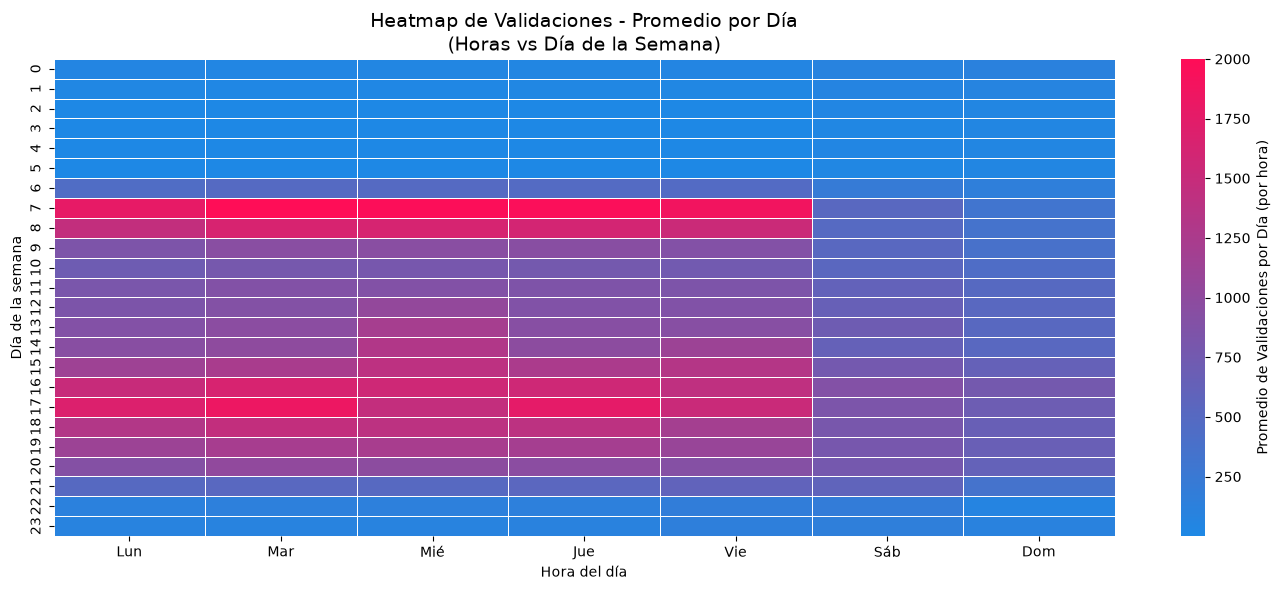

In [22]:
dias_nombres = {0:'Lun', 1:'Mar', 2:'Mié', 3:'Jue', 4:'Vie', 5:'Sáb', 6:'Dom'}
meses_nombres = {
    1: 'Enero', 2: 'Febrero', 3: 'Marzo', 4: 'Abril',
    5: 'Mayo', 6: 'Junio', 7: 'Julio', 8: 'Agosto',
    9: 'Septiembre', 10: 'Octubre', 11: 'Noviembre', 12: 'Diciembre'
}

df_dia_semana = df_val_par.copy()
df_dia_semana.rename(columns={'año': 'year', 'mes': 'month', 'dia': 'day'}, inplace=True)
df_dia_semana['fecha'] = pd.to_datetime(df_dia_semana[['year', 'month', 'day']])
# 2. Calcula cuántos días de cada día de la semana hay en TOTAL
# (ej. si tienes 5 lunes en el dataset, dará 5)
dias_totales_por_semana = df_dia_semana.groupby('dia_semana')['fecha'].nunique()

# 3. Mapeo de nombres
df_dia_semana['dia_semana_nombre'] = df_dia_semana['dia_semana'].map(dias_nombres)

# 4. Pivot con el conteo TOTAL (igual que hacías pero con size)
pivot_raw = df_dia_semana.pivot_table(
    index='hora',
    columns='dia_semana_nombre',
    aggfunc='size',      # Cuenta cuántas filas hay en total
    fill_value=0
)

# 5. ¡AQUÍ ESTÁ LA CLAVE! Dividimos el total de cada día entre la cantidad de días de ese tipo
for dia_num, dia_nom in dias_nombres.items():
    if dia_nom in pivot_raw.columns:
        # Dividimos el conteo total de ese día entre el número de veces que aparece ese día en el dataset
        pivot_raw[dia_nom] = pivot_raw[dia_nom] / dias_totales_por_semana[dia_num]

# 6. Reordenar columnas
orden_dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']
pivot_year = pivot_raw.reindex(columns=orden_dias, fill_value=0)

# 7. Graficar (tu código de gráfico, sin cambios)
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_year, 
            cmap=graph_cmap,
            annot=False,
            cbar_kws={'label': 'Promedio de Validaciones por Día (por hora)'},
            linewidths=0.5,
            linecolor='white')

plt.title('Heatmap de Validaciones - Promedio por Día\n(Horas vs Día de la Semana)', fontsize=14)
plt.xlabel('Hora del día')
plt.ylabel('Día de la semana')
plt.tight_layout()
plt.show()

Heatmaps mensuales de validaciones según el día de la semana

C:\Users\poshiro\AppData\Local\Temp\ipykernel_11820\584992634.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


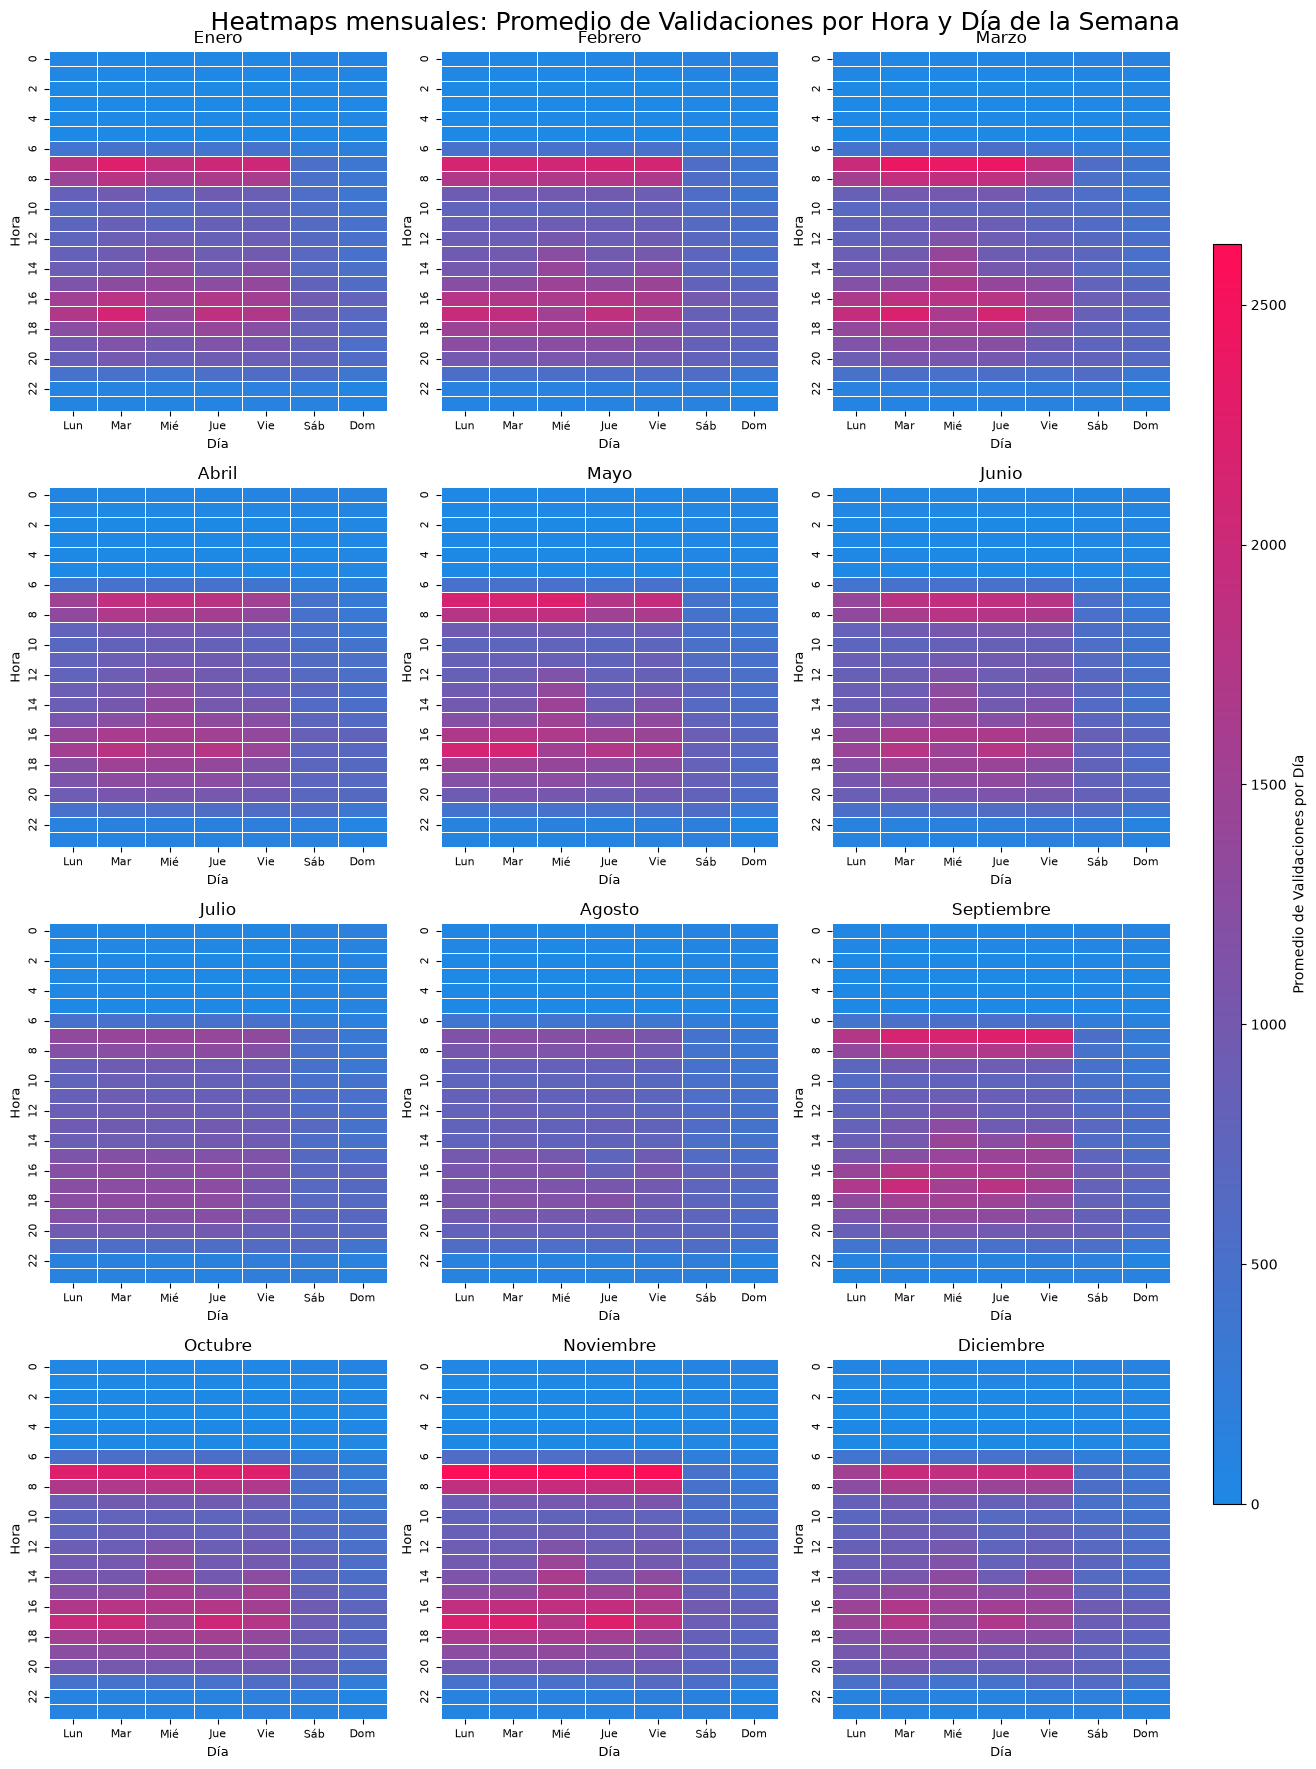

In [23]:
# ---- Calcular global_max basado en promedios ----
global_max = 0
for month in range(1, 13):
    sub = df_dia_semana[df_dia_semana['month'] == month]
    if sub.empty:
        continue
    # Número de días de cada tipo en este mes
    dias_por_tipo = sub.groupby('dia_semana')['fecha'].nunique()
    # Pivote con conteo total (size)
    piv_temp = sub.pivot_table(index='hora', columns='dia_semana_nombre', aggfunc='size', fill_value=0)
    piv_temp = piv_temp.reindex(columns=orden_dias, fill_value=0)
    piv_temp = piv_temp.reindex(index=range(24), fill_value=0)
    # Dividir por número de días de cada tipo
    for dia_num, dia_nom in dias_nombres.items():
        if dia_nom in piv_temp.columns:
            num_dias = dias_por_tipo.get(dia_num, 1)
            piv_temp[dia_nom] = piv_temp[dia_nom] / num_dias
    # Actualizar máximo
    current_max = piv_temp.values.max()
    if current_max > global_max:
        global_max = current_max

if global_max == 0:
    global_max = 1

# ---- Crear figura ----
fig, axes = plt.subplots(4, 3, figsize=(14, 18))
axes_flat = axes.flatten()

for i, month in enumerate(range(1, 13)):
    ax = axes_flat[i]
    sub = df_dia_semana[df_dia_semana['month'] == month]
    
    if sub.empty:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(meses_nombres[month])
        ax.axis('off')
        continue
    
    # Número de días de cada tipo en este mes
    dias_por_tipo = sub.groupby('dia_semana')['fecha'].nunique()
    
    # Pivote con conteo total
    pivot_mes = sub.pivot_table(index='hora', columns='dia_semana_nombre', aggfunc='size', fill_value=0)
    pivot_mes = pivot_mes.reindex(columns=orden_dias, fill_value=0)
    pivot_mes = pivot_mes.reindex(index=range(24), fill_value=0)
    
    # Dividir para obtener promedio por día
    for dia_num, dia_nom in dias_nombres.items():
        if dia_nom in pivot_mes.columns:
            num_dias = dias_por_tipo.get(dia_num, 1)
            pivot_mes[dia_nom] = pivot_mes[dia_nom] / num_dias
    
    # Heatmap
    sns.heatmap(pivot_mes,
                ax=ax,
                cmap=graph_cmap,
                cbar=False,
                vmin=0,
                vmax=global_max,
                annot=False,
                linewidths=0.5,
                linecolor='white')
    
    ax.set_title(meses_nombres[month], fontsize=12)
    ax.set_xlabel('Día', fontsize=9)
    ax.set_ylabel('Hora', fontsize=9)
    ax.tick_params(labelsize=8)

# Ajustes y barra de color común
plt.subplots_adjust(right=0.85, top=0.92)
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=graph_cmap, norm=plt.Normalize(vmin=0, vmax=global_max))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Promedio de Validaciones por Día')
fig.suptitle('Heatmaps mensuales: Promedio de Validaciones por Hora y Día de la Semana', fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

## Viajes por usuario

In [24]:
# registros con mayores viajes por usuario
# 1. Ordenamos el DataFrame por 'viajes_por_usuario' de mayor a menor (global)
df_viajes_usuario = df_val_par.sort_values('viajes_por_usuario', ascending=False)

# 2. Nos quedamos con el primer registro de cada RFID (el que tenga mayor viajes_por_usuario, aunque todos son iguales)
df_viajes_usuario = df_viajes_usuario.drop_duplicates(subset='rfid', keep='first')

# 3. Mostramos los 10 primeros (los que tienen más viajes)
df_viajes_usuario.head(10)

,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
5794809,42.445850,1.481620,False,5693694,482340,972424,9206,28071,29010,1767206186,...,31,12,2025,18,36,26,5017,1776,3.032954,2.176328
5793450,42.536989,1.583471,False,5693694,545896,1182733,4792,71839,22197,1767200847,...,31,12,2025,17,7,27,21416,1521,6.325391,1.063289
4750891,42.507134,1.519262,False,5693694,478357,972424,4659,23844,35423,1761772201,...,29,10,2025,21,10,1,19673,1354,1.669718,0.305545
5280976,42.476684,1.490246,True,5693694,390432,798292,9005,37593,28776,1764356383,...,28,11,2025,18,59,43,5378,1331,0.927273,0.620711
5789127,42.514890,1.531674,False,5693694,88332,272299,1450,28180,16730,1767183148,...,31,12,2025,12,12,28,52144,1310,0.610531,0.042151
5785304,42.534854,1.581280,False,5693694,642521,1182733,1438,25702,19598,1767166326,...,31,12,2025,7,32,6,87380,1306,0.000000,0.000000
5755012,42.566972,1.600500,False,5693694,328198,793960,22384,54838,42212,1766992102,...,29,12,2025,7,8,22,247431,1290,0.000000,0.000000
5794550,42.504115,1.520572,False,103182,129548,260389,1915,379064,20915,1767205163,...,31,12,2025,18,19,23,40093,1283,6.266185,0.562648
5792234,42.491963,1.496468,False,5693694,482340,972424,6863,31336,19413,1767196379,...,31,12,2025,15,52,59,16534,1265,0.000000,0.000000
5792993,42.535348,1.581425,False,5693694,545896,1182733,936,169633,22059,1767199135,...,31,12,2025,16,38,55,3015,1248,4.776025,5.702717


In [25]:
df_viajes_usuario.describe()

,latitude,longitude,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,dia_semana,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
count,50835.000000,50835.000000,5.083500e+04,50835.000000,5.083500e+04,50835.000000,50835.000000,50835.000000,5.083500e+04,50835.000000,50835.000000,50835.000000,50835.0,50835.000000,50835.000000,50835.000000,5.083500e+04,50835.000000,50835.000000,50835.000000
mean,42.515633,1.537257,5.436026e+06,382284.918934,8.046178e+05,6572.029094,137645.630274,25417.000000,1.761467e+09,2.549503,20.351313,10.172775,2025.0,14.571103,28.976788,29.546336,1.003009e+06,114.033166,3.077081,1.180549
std,0.027307,0.045980,1.172234e+06,177119.057974,3.027141e+05,6822.890702,114208.242225,14674.944804,8.037297e+06,1.794703,9.093901,2.955365,0.0,4.224062,17.478031,17.349982,2.911337e+06,156.365313,3.787809,3.616548
min,42.445850,1.478990,1.031820e+05,168.000000,4.587000e+03,12.000000,44.000000,0.000000,1.735699e+09,0.000000,1.000000,1.000000,2025.0,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000
25%,42.504115,1.515481,5.693694e+06,255189.000000,7.925330e+05,1798.000000,40351.000000,12708.500000,1.758969e+09,1.000000,14.000000,9.000000,2025.0,12.000000,14.000000,14.000000,8.738500e+03,11.000000,0.000000,0.000000
50%,42.508806,1.528001,5.693694e+06,414537.000000,7.982920e+05,4490.000000,104224.000000,25417.000000,1.765642e+09,2.000000,22.000000,12.000000,2025.0,15.000000,29.000000,30.000000,4.991700e+04,48.000000,1.701339,0.025975
75%,42.533271,1.535620,5.693694e+06,482340.000000,9.724240e+05,9187.000000,174383.000000,38125.500000,1.766948e+09,4.000000,29.000000,12.000000,2025.0,18.000000,44.000000,45.000000,4.401055e+05,156.000000,5.003448,0.950347
max,42.632028,1.734056,5.693694e+06,642521.000000,1.182733e+06,36884.000000,379064.000000,50834.000000,1.767225e+09,6.000000,31.000000,12.000000,2025.0,23.000000,59.000000,59.000000,3.065123e+07,1776.000000,23.414252,205.706331


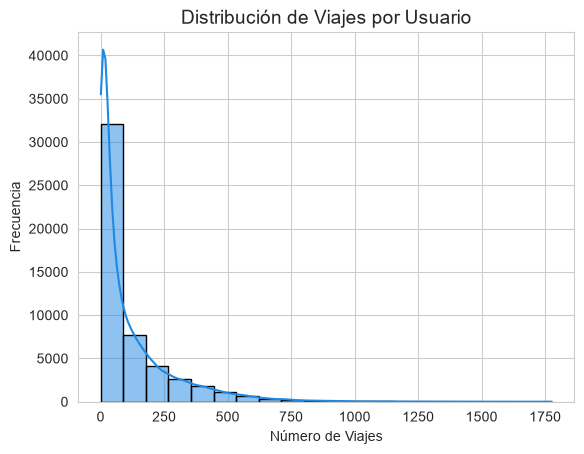

In [26]:
# Estilo bonito
sns.set_style("whitegrid")

# Crear el histograma con curva de densidad (KDE)
sns.histplot(
    data=df_viajes_usuario, 
    x='viajes_por_usuario', 
    bins=20, 
    kde=True,        # Añade una línea suave que estima la densidad
    color=graph_palette[0],
    edgecolor='black'
)

plt.title('Distribución de Viajes por Usuario', fontsize=14)
plt.xlabel('Número de Viajes')
plt.ylabel('Frecuencia')
plt.show()

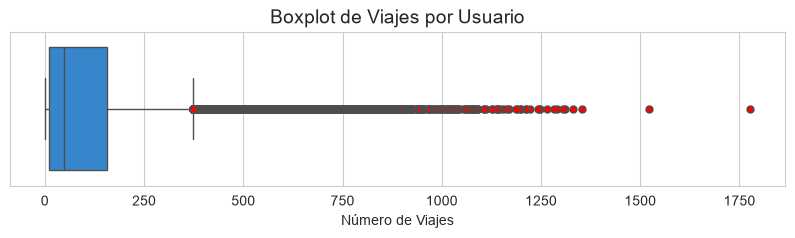

In [27]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 2))  

# Boxplot horizontal (recomendado para leer los cuartiles mejor)
sns.boxplot(
    data=df_viajes_usuario, 
    x='viajes_por_usuario',  # 'x' para horizontal, 'y' para vertical
    color=graph_palette[0],
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5}  # Personalizar outliers
)

plt.title('Boxplot de Viajes por Usuario', fontsize=14)
plt.xlabel('Número de Viajes')
plt.show()

In [28]:
top_rfid = df_viajes_usuario.head(10)['rfid'].tolist()
meses_nombres = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
                 7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

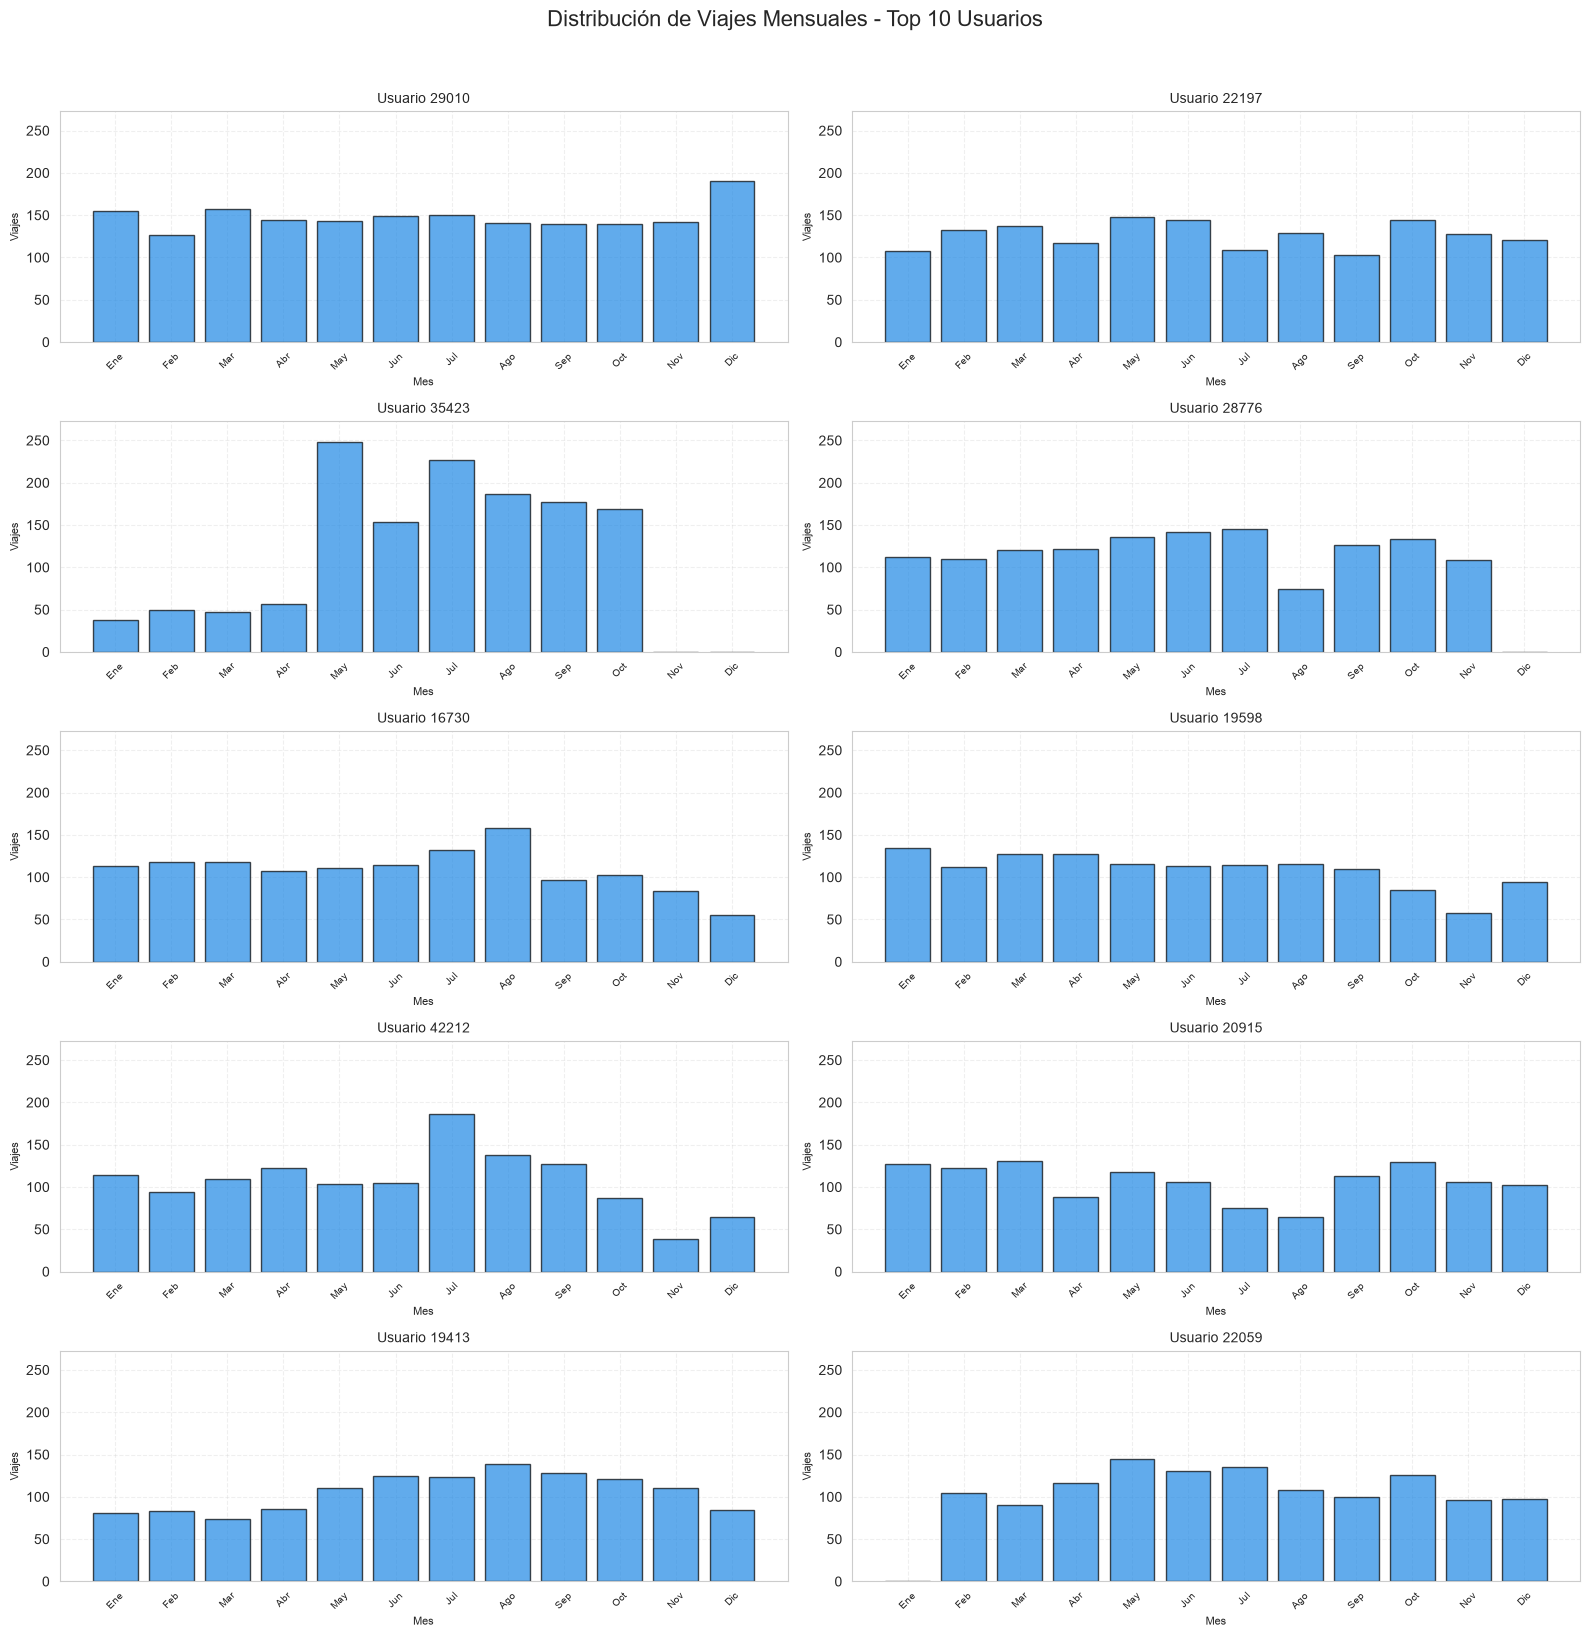

In [29]:
# ------------------------------------------------------------
# 1. CALCULAR EL MÁXIMO GLOBAL ANTES DE DIBUJAR
#    (Así todos los gráficos comparten la misma escala)
# ------------------------------------------------------------
max_viajes = 0
for rfid in top_rfid:
    df_user = df_val_par[df_val_par['rfid'] == rfid]
    viajes_mes = df_user['mes'].value_counts().sort_index()
    viajes_mes = viajes_mes.reindex(range(1, 13), fill_value=0)
    max_viajes = max(max_viajes, viajes_mes.max())

# Añadimos un pequeño margen superior del 10% para que no se corten las barras
limite_superior = max_viajes * 1.1

# ------------------------------------------------------------
# 2. CREAR LA FIGURA Y LOS EJES
# ------------------------------------------------------------
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 16))
axes_flat = axes.flatten()

# ------------------------------------------------------------
# 3. BUCLE PARA DIBUJAR CADA SUBPLOT
# ------------------------------------------------------------
for i, rfid in enumerate(top_rfid):
    # Filtrar los viajes de este usuario específico
    df_user = df_val_par[df_val_par['rfid'] == rfid]
    viajes_mes = df_user['mes'].value_counts().sort_index()
    viajes_mes = viajes_mes.reindex(range(1, 13), fill_value=0)
    viajes_mes.index = [meses_nombres[m] for m in viajes_mes.index]
    
    # Seleccionar el eje correspondiente
    ax = axes_flat[i]
    
    # Dibujar barras
    ax.bar(viajes_mes.index, 
           viajes_mes.values,
           color=graph_palette[0], 
           edgecolor='black', 
           alpha=0.7)
    
    # Títulos y etiquetas
    ax.set_title(f'Usuario {rfid}', fontsize=10)
    ax.set_xlabel('Mes', fontsize=8)
    ax.set_ylabel('Viajes', fontsize=8)
    
    # Cuadrícula ligera
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # ------------------------------------------------------------
    # MEJORA 1: INCLINAR ETIQUETAS DEL EJE X (para que no se solapen)
    # ------------------------------------------------------------
    ax.tick_params(axis='x', rotation=45, labelsize=7)  # 45° es lo estándar
    
    # ------------------------------------------------------------
    # MEJORA 2: MISMA ESCALA EN Y PARA TODOS
    # ------------------------------------------------------------
    ax.set_ylim(0, limite_superior)

# ------------------------------------------------------------
# 4. OCULTAR LOS EJES SOBRANTES (si top_rfid tiene menos de 10)
# ------------------------------------------------------------
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

# ------------------------------------------------------------
# 5. TÍTULO GENERAL Y AJUSTE FINAL
# ------------------------------------------------------------
plt.suptitle('Distribución de Viajes Mensuales - Top 10 Usuarios', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Los viajes se reparten de manera bastante regular entre los meses en la mayoría de casos con lo que parece un comportamiento habitual. En el caso del usuario 35423 parece que haya habido mayor uso durante la segunda mitad del año, vamos a explorar más en detalle su caso:

In [30]:
df_val_par[(df_val_par['rfid']==35423)].sort_values('speed', ascending=False).head(20)

,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
4032048,42.511306,1.538806,True,5693694,482340,972424,6358,226112,35423,1758145454,...,17,9,2025,21,44,14,495,1093,6.081636,44.230079
3742818,42.445850,1.481620,False,5693694,482340,972424,10720,28071,35423,1756497337,...,29,8,2025,19,55,37,388,997,2.684971,24.912102
4577164,42.504115,1.520572,False,5693694,171573,792533,900,379064,35423,1760904801,...,19,10,2025,20,13,21,687,1333,4.573657,23.966761
2794994,42.468548,1.492673,False,5693694,390432,798292,4478,253447,35423,1750622579,...,22,6,2025,20,2,59,990,578,6.083248,22.120900
3373567,42.511306,1.538806,True,5693694,482340,972424,6358,226112,35423,1753997975,...,31,7,2025,21,39,35,1015,821,6.081636,21.570334
1988412,42.511306,1.538806,True,5693694,482340,972424,6358,226112,35423,1746390518,...,4,5,2025,20,28,38,1141,218,6.229477,19.654790
3356865,42.507380,1.532940,False,5693694,414537,798292,2055,104224,35423,1753911650,...,30,7,2025,21,40,50,1037,814,5.441091,18.889032
2090771,42.556724,1.534741,False,5693694,190778,792533,380,22300,35423,1746893424,...,10,5,2025,16,10,24,1025,269,5.218210,18.327373
3742736,42.468548,1.492673,False,5693694,478357,972424,6844,253447,35423,1756496949,...,29,8,2025,19,49,9,1203,996,6.083248,18.204232
3086207,42.496430,1.500788,False,5693694,478357,972424,4659,30235,35423,1752268649,...,11,7,2025,21,17,29,658,668,3.174433,17.367717


No da indicios de fraude.

In [31]:
df_top_viajes = df_val_par[df_val_par['rfid'].isin(top_rfid)].sort_values('speed', ascending=False)
df_top_viajes.head()

,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
1104817,42.569861,1.604820,False,103182,131434,260389,3252,5637,20915,1741595394,...,10,3,2025,8,29,54,53,282,4.295589,291.775863
608261,42.534078,1.585210,False,103182,545896,1182733,3413,49077,20915,1738945228,...,7,2,2025,16,20,28,162,159,9.467522,210.389376
4529397,42.487861,1.490444,False,5693694,11220,92396,10105,19388,20915,1760630544,...,16,10,2025,16,2,24,203,1019,9.326655,165.398808
2173763,42.534078,1.585210,False,103182,328198,793960,7437,49077,20915,1747325347,...,15,5,2025,16,9,7,276,516,9.321859,121.589471
3027828,42.468548,1.492673,False,5693694,390432,798292,5773,253447,22197,1751976654,...,8,7,2025,12,10,54,315,822,8.921462,101.959571


Además observando las mayores velocidades también encontramos al usuario 20915, con una velocidad demasiado elevada en varios trayectos.

In [32]:
df_val_par[(df_val_par['rfid']==20915)].sort_values('speed', ascending=False).head()

,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
1104817,42.569861,1.604820,False,103182,131434,260389,3252,5637,20915,1741595394,...,10,3,2025,8,29,54,53,282,4.295589,291.775863
608261,42.534078,1.585210,False,103182,545896,1182733,3413,49077,20915,1738945228,...,7,2,2025,16,20,28,162,159,9.467522,210.389376
4529397,42.487861,1.490444,False,5693694,11220,92396,10105,19388,20915,1760630544,...,16,10,2025,16,2,24,203,1019,9.326655,165.398808
2173763,42.534078,1.585210,False,103182,328198,793960,7437,49077,20915,1747325347,...,15,5,2025,16,9,7,276,516,9.321859,121.589471
2406774,42.534078,1.585210,False,103182,545896,1182733,4828,49077,20915,1748527922,...,29,5,2025,14,12,2,287,577,5.550130,69.618361


In [33]:
df_val_par[(df_val_par['rfid']==20915)].sort_values('viajes_por_usuario').iloc[280:290]

,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
1104790,42.534078,1.585210,True,103182,545896,1182733,8609,49077,20915,1741595341,...,10,3,2025,8,29,1,5269,281,0.000000,0.000000
1104817,42.569861,1.604820,False,103182,131434,260389,3252,5637,20915,1741595394,...,10,3,2025,8,29,54,53,282,4.295589,291.775863
1108108,42.534078,1.585210,True,103182,545896,1182733,8609,49077,20915,1741607217,...,10,3,2025,11,46,57,11823,283,4.295934,1.308074
1110233,42.507922,1.527608,False,103182,129548,260389,1606,174383,20915,1741615495,...,10,3,2025,14,4,55,8278,284,5.551815,2.414416
1112401,42.487861,1.490444,False,5693694,11220,92396,10105,19388,20915,1741622277,...,10,3,2025,15,57,57,6782,285,3.780736,2.006878
1113410,42.534078,1.585210,False,103182,545896,1182733,7176,49077,20915,1741624049,...,10,3,2025,16,27,29,1772,286,9.321859,18.938315
1114528,42.534078,1.585210,False,103182,465386,793960,1826,49077,20915,1741626134,...,10,3,2025,17,2,14,2085,287,0.000000,0.000000
1119849,42.507922,1.527608,False,103182,129548,260389,4983,174383,20915,1741638730,...,10,3,2025,20,32,10,12596,288,5.551815,1.586737
1121596,42.534078,1.585210,False,5693694,6248,92396,5952,49077,20915,1741676481,...,11,3,2025,7,1,21,37751,289,5.550130,0.529270
1125890,42.534854,1.581280,False,103182,642521,1182733,6328,25702,20915,1741683705,...,11,3,2025,9,1,45,7224,290,0.333725,0.166308


No lo podemos dar por fraudulento aunque el comportamiento sea muy raro debido a que la primera parada ha sido imputada.

In [34]:
df_val_par[(df_val_par['rfid']==20915)].sort_values('viajes_por_usuario').iloc[150:160]

,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
585153,42.507325,1.528001,False,103182,465386,793960,2779,164738,20915,1738851668,...,6,2,2025,14,21,8,603,151,5.559721,33.192366
587343,42.534078,1.585210,False,103182,328198,793960,2209,49077,20915,1738858012,...,6,2,2025,16,6,52,6344,152,5.558024,3.153986
594325,42.534078,1.585210,True,103182,545896,1182733,8609,49077,20915,1738873919,...,6,2,2025,20,31,59,15907,153,0.000000,0.000000
596136,42.534078,1.585210,True,5693694,545896,1182733,8609,49077,20915,1738911660,...,7,2,2025,7,1,0,37741,154,0.000000,0.000000
599513,42.534078,1.585210,True,103182,545896,1182733,8609,49077,20915,1738916798,...,7,2,2025,8,26,38,5138,155,0.000000,0.000000
605171,42.507922,1.527608,False,103182,465386,793960,2779,174383,20915,1738937810,...,7,2,2025,14,16,50,21012,156,5.551815,0.951196
606780,42.534078,1.585210,True,103182,545896,1182733,8609,49077,20915,1738941960,...,7,2,2025,15,26,0,4150,157,5.550130,4.814571
608153,42.484682,1.491255,False,5693694,482340,972424,19690,35663,20915,1738945066,...,7,2,2025,16,17,46,3106,158,9.472482,10.979052
608261,42.534078,1.585210,False,103182,545896,1182733,3413,49077,20915,1738945228,...,7,2,2025,16,20,28,162,159,9.467522,210.389376
608869,42.534078,1.585210,True,5693694,545896,1182733,8609,49077,20915,1738946675,...,7,2,2025,16,44,35,1447,160,0.000000,0.000000


Esto es un caso de fraude. Se valida mediante la tarjeta física y QR de la app en dos líneas diferentes, en extremos opuestos con una diferencia de 3 minutos.

## Delta time

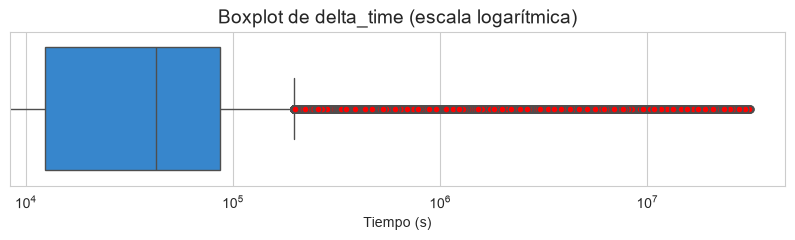

In [35]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 2))  

# Boxplot horizontal (recomendado para leer los cuartiles mejor)
sns.boxplot(
    data=df_val_par, 
    x='delta_time',  # 'x' para horizontal, 'y' para vertical
    color=graph_palette[0],
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5}
)

plt.xscale('log')
plt.title('Boxplot de delta_time (escala logarítmica)', fontsize=14)
plt.xlabel('Tiempo (s)')
plt.show()

In [36]:
# registros con menor delta time
top_10_delta_time = df_val_par[(df_val_par['viajes_por_usuario'] != 1)&(df_val_par['delta_distance'] != 0)].sort_values('delta_time').head(10)
top_10_delta_time

,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
3686260,42.506520,1.531690,False,5693694,465386,793960,15575,112990,19458,1756157443,...,25,8,2025,21,30,43,2,300,13.273589,23892.460047
4707488,42.445850,1.481620,False,5693694,482340,972424,5721,28071,41746,1761567437,...,27,10,2025,12,17,17,3,483,2.684971,3221.965152
3653305,42.507556,1.534250,False,5693694,282612,525612,2633,16215,16142,1755897985,...,22,8,2025,21,26,25,4,261,8.669564,7802.607503
1264656,42.461872,1.490235,False,103182,390432,798292,3858,89688,28739,1742404771,...,19,3,2025,17,19,31,5,298,6.796546,4893.513029
3294844,42.504115,1.520572,True,103182,255189,525612,9210,379064,177,1753558434,...,26,7,2025,19,33,54,11,174,6.450087,2110.937601
3847711,42.507922,1.527608,False,5693694,23568,31044,10801,174383,4105,1757120518,...,6,9,2025,1,1,58,13,272,5.369055,1486.815325
325168,42.457931,1.487513,False,103182,482340,972424,14308,12146,19776,1737558238,...,22,1,2025,15,3,58,13,35,22.378309,6197.070156
1521227,42.508806,1.531111,False,5693694,273433,792533,3638,306373,23768,1743682080,...,3,4,2025,12,8,0,17,268,8.109853,1717.380635
2526956,42.540182,1.519406,True,5693694,273433,792533,7822,38347,16906,1749139090,...,5,6,2025,15,58,10,17,336,6.290122,1332.025877
811310,42.445850,1.481620,False,103182,482340,972424,12102,28071,28739,1739978232,...,19,2,2025,15,17,12,18,201,8.669531,1733.906247


In [37]:
for row in top_10_delta_time.itertuples():
    rfid = row.rfid
    viaje = row.viajes_por_usuario
    inicio = viaje-2
    
    # Filtrar los viajes de este usuario
    df_user = df_val_par[df_val_par['rfid'] == rfid]
    display(df_user.iloc[inicio : viaje])

# display(df_val_par[(df_val_par['rfid'] == 19458)].iloc[298:300]) #fraude
# display(df_val_par[(df_val_par['rfid'] == 41746)].iloc[483:485])
# display(df_val_par[(df_val_par['rfid'] == 16142)].iloc[259:261]) #fraude
# display(df_val_par[(df_val_par['rfid'] == 28739)].iloc[296:298]) #fraude
# display(df_val_par[(df_val_par['rfid'] == 177)].iloc[172:174]) #fraude
# display(df_val_par[(df_val_par['rfid'] == 4105)].iloc[270:272])
# display(df_val_par[(df_val_par['rfid'] == 19776)].iloc[33:35])
# display(df_val_par[(df_val_par['rfid'] == 23768)].iloc[266:268]) #fraude
# display(df_val_par[(df_val_par['rfid'] == 16906)].iloc[334:336]) 
# display(df_val_par[(df_val_par['rfid'] == 28739)].iloc[199:201]) #fraude

,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
3686259,42.579806,1.659278,True,5693694,328198,793960,8777,20488,19458,1756157441,...,25,8,2025,21,30,41,36315,299,0.000000,0.000000
3686260,42.506520,1.531690,False,5693694,465386,793960,15575,112990,19458,1756157443,...,25,8,2025,21,30,43,2,300,13.273589,23892.460047


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
4707485,42.468548,1.492673,False,103182,390432,798292,5773,253447,41746,1761567434,...,27,10,2025,12,17,14,3136,482,6.083248,6.983320
4707488,42.445850,1.481620,False,5693694,482340,972424,5721,28071,41746,1761567437,...,27,10,2025,12,17,17,3,483,2.684971,3221.965152


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
3653304,42.575024,1.481479,True,5693694,255189,525612,2633,16133,16142,1755897981,...,22,8,2025,21,26,21,36264,260,0.000000,0.000000
3653305,42.507556,1.534250,False,5693694,282612,525612,2633,16215,16142,1755897985,...,22,8,2025,21,26,25,4,261,8.669564,7802.607503


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
1264651,42.511306,1.538806,True,103182,478357,972424,5516,226112,28739,1742404766,...,19,3,2025,17,19,26,14071,297,5.543730,1.418337
1264656,42.461872,1.490235,False,103182,390432,798292,3858,89688,28739,1742404771,...,19,3,2025,17,19,31,5,298,6.796546,4893.513029


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
3294837,42.534722,1.587306,False,103182,545896,1182733,1809,86490,177,1753558423,...,26,7,2025,19,33,43,13900,173,6.447810,1.669936
3294844,42.504115,1.520572,True,103182,255189,525612,9210,379064,177,1753558434,...,26,7,2025,19,33,54,11,174,6.450087,2110.937601


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
3847709,42.535348,1.581425,True,5693694,545896,1182733,36884,169633,4105,1757120505,...,6,9,2025,1,1,45,14662,271,0.000000,0.000000
3847711,42.507922,1.527608,False,5693694,23568,31044,10801,174383,4105,1757120518,...,6,9,2025,1,1,58,13,272,5.369055,1486.815325


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
325162,42.543528,1.734056,True,103182,465386,793960,9168,150016,19776,1737558225,...,22,1,2025,15,3,45,10178,34,0.000000,0.000000
325168,42.457931,1.487513,False,103182,482340,972424,14308,12146,19776,1737558238,...,22,1,2025,15,3,58,13,35,22.378309,6197.070156


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
1521220,42.572769,1.483805,True,5693694,255189,525612,3453,38073,23768,1743682063,...,3,4,2025,12,7,43,5633,267,4.056342,2.592372
1521227,42.508806,1.531111,False,5693694,273433,792533,3638,306373,23768,1743682080,...,3,4,2025,12,8,0,17,268,8.109853,1717.380635


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
2526936,42.487861,1.490444,False,5693694,4352,92396,7822,19388,16906,1749139073,...,5,6,2025,15,57,53,28845,335,6.290874,0.785132
2526956,42.540182,1.519406,True,5693694,273433,792533,7822,38347,16906,1749139090,...,5,6,2025,15,58,10,17,336,6.290122,1332.025877


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
811301,42.511306,1.538806,True,103182,478357,972424,5516,226112,28739,1739978214,...,19,2,2025,15,16,54,23750,200,0.650162,0.098551
811310,42.445850,1.481620,False,103182,482340,972424,12102,28071,28739,1739978232,...,19,2,2025,15,17,12,18,201,8.669531,1733.906247


## Speed

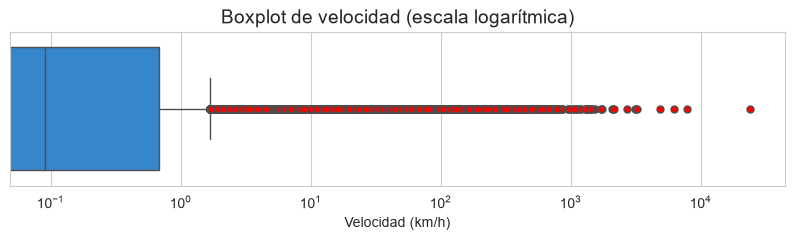

In [38]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 2))  

# Boxplot horizontal (recomendado para leer los cuartiles mejor)
sns.boxplot(
    data=df_val_par, 
    x='speed',  # 'x' para horizontal, 'y' para vertical
    color=graph_palette[0],
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5}
)

plt.xscale('log')
plt.title('Boxplot de velocidad (escala logarítmica)', fontsize=14)
plt.xlabel('Velocidad (km/h)')
plt.show()

In [39]:
(df_val_par['speed'] > 100).sum()

np.int64(1019)

In [40]:
# registros con mayor velocidad
top_10_speed = df_val_par.sort_values('speed', ascending=False).head(10)
top_10_speed

,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
3686260,42.506520,1.531690,False,5693694,465386,793960,15575,112990,19458,1756157443,...,25,8,2025,21,30,43,2,300,13.273589,23892.460047
3653305,42.507556,1.534250,False,5693694,282612,525612,2633,16215,16142,1755897985,...,22,8,2025,21,26,25,4,261,8.669564,7802.607503
325168,42.457931,1.487513,False,103182,482340,972424,14308,12146,19776,1737558238,...,22,1,2025,15,3,58,13,35,22.378309,6197.070156
1264656,42.461872,1.490235,False,103182,390432,798292,3858,89688,28739,1742404771,...,19,3,2025,17,19,31,5,298,6.796546,4893.513029
4707488,42.445850,1.481620,False,5693694,482340,972424,5721,28071,41746,1761567437,...,27,10,2025,12,17,17,3,483,2.684971,3221.965152
2040103,42.487861,1.490444,False,5693694,4037,92396,5372,19388,25010,1746633603,...,7,5,2025,16,0,3,20,286,17.535322,3156.357891
1031068,42.543528,1.734056,True,5693694,465386,793960,13924,150016,17121,1741190397,...,5,3,2025,15,59,57,24,100,20.919130,3137.869575
2040099,42.487861,1.490444,False,5693694,4037,92396,5372,19388,46678,1746633601,...,7,5,2025,16,0,1,22,303,16.567573,2711.057378
5195084,42.491963,1.496468,False,5693694,482340,972424,4839,31336,36640,1764010322,...,24,11,2025,18,52,2,28,151,16.868778,2168.842874
3294844,42.504115,1.520572,True,103182,255189,525612,9210,379064,177,1753558434,...,26,7,2025,19,33,54,11,174,6.450087,2110.937601


In [41]:
for row in top_10_speed.itertuples():
    rfid = row.rfid
    viaje = row.viajes_por_usuario
    inicio = viaje-2
    
    # Filtrar los viajes de este usuario
    df_user = df_val_par[df_val_par['rfid'] == rfid]
    display(df_user.iloc[inicio : viaje])

,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
3686259,42.579806,1.659278,True,5693694,328198,793960,8777,20488,19458,1756157441,...,25,8,2025,21,30,41,36315,299,0.000000,0.000000
3686260,42.506520,1.531690,False,5693694,465386,793960,15575,112990,19458,1756157443,...,25,8,2025,21,30,43,2,300,13.273589,23892.460047


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
3653304,42.575024,1.481479,True,5693694,255189,525612,2633,16133,16142,1755897981,...,22,8,2025,21,26,21,36264,260,0.000000,0.000000
3653305,42.507556,1.534250,False,5693694,282612,525612,2633,16215,16142,1755897985,...,22,8,2025,21,26,25,4,261,8.669564,7802.607503


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
325162,42.543528,1.734056,True,103182,465386,793960,9168,150016,19776,1737558225,...,22,1,2025,15,3,45,10178,34,0.000000,0.000000
325168,42.457931,1.487513,False,103182,482340,972424,14308,12146,19776,1737558238,...,22,1,2025,15,3,58,13,35,22.378309,6197.070156


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
1264651,42.511306,1.538806,True,103182,478357,972424,5516,226112,28739,1742404766,...,19,3,2025,17,19,26,14071,297,5.543730,1.418337
1264656,42.461872,1.490235,False,103182,390432,798292,3858,89688,28739,1742404771,...,19,3,2025,17,19,31,5,298,6.796546,4893.513029


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
4707485,42.468548,1.492673,False,103182,390432,798292,5773,253447,41746,1761567434,...,27,10,2025,12,17,14,3136,482,6.083248,6.983320
4707488,42.445850,1.481620,False,5693694,482340,972424,5721,28071,41746,1761567437,...,27,10,2025,12,17,17,3,483,2.684971,3221.965152


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
2040080,42.576889,1.666667,True,5693694,6573,92396,13924,75780,25010,1746633583,...,7,5,2025,15,59,43,32145,285,5.890497,0.659692
2040103,42.487861,1.490444,False,5693694,4037,92396,5372,19388,25010,1746633603,...,7,5,2025,16,0,3,20,286,17.535322,3156.357891


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
1031047,42.487861,1.490444,False,5693694,4352,92396,7822,19388,17121,1741190373,...,5,3,2025,15,59,33,33660,99,20.936138,2.239159
1031068,42.543528,1.734056,True,5693694,465386,793960,13924,150016,17121,1741190397,...,5,3,2025,15,59,57,24,100,20.919130,3137.869575


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
2040075,42.579472,1.649500,True,5693694,465386,793960,13924,62704,46678,1746633579,...,7,5,2025,15,59,39,32623,302,0.000000,0.000000
2040099,42.487861,1.490444,False,5693694,4037,92396,5372,19388,46678,1746633601,...,7,5,2025,16,0,1,22,303,16.567573,2711.057378


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
5195072,42.576889,1.666667,True,103182,465386,793960,10801,75780,36640,1764010294,...,24,11,2025,18,51,34,34239,150,0.000000,0.000000
5195084,42.491963,1.496468,False,5693694,482340,972424,4839,31336,36640,1764010322,...,24,11,2025,18,52,2,28,151,16.868778,2168.842874


,latitude,longitude,coord_imputada,Tipus validació_freq,Ruta_freq,Línia_freq,Viatge_freq,Parada_freq,rfid,timestamp,...,dia,mes,año,hora,minuto,segundo,delta_time,viajes_por_usuario,delta_distance,speed
3294837,42.534722,1.587306,False,103182,545896,1182733,1809,86490,177,1753558423,...,26,7,2025,19,33,43,13900,173,6.447810,1.669936
3294844,42.504115,1.520572,True,103182,255189,525612,9210,379064,177,1753558434,...,26,7,2025,19,33,54,11,174,6.450087,2110.937601


## Subconjunto de fraude

In [42]:
fraud_idx = [608261, 4707488, 1264656, 3294844, 325168, 811310, 5195084]
df_fraud = df_val_par.iloc[fraud_idx].copy()

# Estudio de algoritmos de Machine Learning

## Isolation Forest

### Datos

In [43]:
iso_forest_data = df_val_par.drop(columns='coord_imputada')

# definicion de conjuntos de caracteristicas
all_features = list(iso_forest_data.columns)
timestamp_features = ['timestamp']
time_features = ['dia_semana', 'dia', 'mes', 'año', 'hora', 'minuto', 'segundo']
freq_features = ['Ruta_freq', 'Línia_freq', 'Viatge_freq', 'Parada_freq', 'Tipus validació_freq']
id_features = ['rfid']
speed_features = ['speed']

if_data_1 = all_features
if_data_2 = [col for col in all_features if col not in timestamp_features]
if_data_3 = [col for col in all_features if col not in timestamp_features + time_features]
if_data_4 = [col for col in all_features if col not in timestamp_features + time_features + freq_features]
if_data_5 = [col for col in all_features if col not in timestamp_features + time_features + freq_features + id_features]
if_data_6 = [col for col in all_features if col not in timestamp_features + time_features + freq_features + id_features + speed_features]

feature_sets = {
    "completo": if_data_1,
    "sin_timestamp": if_data_2,
    "sin_timestamp_hora": if_data_3,
    "sin_timestamp_hora_frecuencia": if_data_4,
    "sin_timestamp_hora_frecuencia_id": if_data_5,
    "sin_timestamp_hora_frecuencia_id_velocidad": if_data_6
}

#feature_sets = {
#    "completo": if_data_1
#}

### Entrenamiento

In [44]:
# funcion de ejecucion
def run_isolation_forest(X_data, n_outliers=1000, return_pipeline = False):
    n_features = X_data.shape[1]
    
    max_feat = int(math.sqrt(n_features))

    # Pipeline
    pipeline = Pipeline([('scaler', StandardScaler()),('iso_forest', IsolationForest(
        n_estimators=100,               # aumentar 200 o 300
        max_samples=512,             # Usa hasta 10000
        contamination='auto',             # Esperamos ~0.002% de anomalías (ajústalo según tu intuición)
        max_features=max_feat,               # Usa sqrt de la cantidad de columnas
        random_state=42,
        n_jobs=-1                       # Usa todos los núcleos
    ))])

    # Ajustar el pipeline
    pipeline.fit(X_data)
    # Obtener los scores de anomalía
    scores = pipeline.named_steps['iso_forest'].decision_function(X_data)

    sorted_indices = np.argsort(scores)
    outlier_indices = sorted_indices[:n_outliers]
    inlier_indices = sorted_indices[n_outliers:]
    labels = np.ones(len(X_data), dtype=int)  # -1
    labels[outlier_indices] = -1

    outlier_scores = scores[labels == -1]
    inlier_scores = scores[labels == 1]
        
    result = {
        'kurtosis': pd.Series(scores).kurtosis(),
        'gap': (np.mean(scores)-np.median(scores))/(np.std(scores)+1e-9),
        'outlier_mean': np.mean(outlier_scores),
        'inlier_mean': np.mean(inlier_scores),
        'labels': labels,
        'scores': scores,
        'outlier_indices': outlier_indices,
        'inlier_indices': inlier_indices
    }

    if return_pipeline:
        result['pipeline'] = pipeline

    return result

In [45]:
outliers_dict = {}  # Diccionario para almacenar los DataFrames de outliers por conjunto
metrics_dict = {}

for name, cols in feature_sets.items():
    print(f"🔍 Probando: {name} ({len(cols)} columnas)")
    X_subset = iso_forest_data[cols]

    result = run_isolation_forest(X_subset, n_outliers=1000)
    
    scores = result['scores']
    outlier_mean = result['outlier_mean']
    inlier_mean = result['inlier_mean']
    outlier_indices = result['outlier_indices']
    
    # Percentiles 5 y 95
    p5 = np.percentile(scores, 5)
    p95 = np.percentile(scores, 95)
    tail_ratio = p5 / p95   # Normalmente negativo si los outliers están a la izquierda
    

    metrics_dict[name] = {
        'kurtosis': result['kurtosis'],
        'gap': result['gap'],
        'outlier_mean': outlier_mean,
        'inlier_mean': inlier_mean,
        'tail_ratio': tail_ratio
    }

    # Guardamos SOLO esas filas del DataFrame original
    outliers_dict[name] = iso_forest_data.iloc[outlier_indices]

🔍 Probando: completo (20 columnas)


c:\Users\poshiro\Documents\tfm\.venv312\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


🔍 Probando: sin_timestamp (19 columnas)


c:\Users\poshiro\Documents\tfm\.venv312\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


🔍 Probando: sin_timestamp_hora (12 columnas)


...

c:\Users\poshiro\Documents\tfm\.venv312\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


🔍 Probando: sin_timestamp_hora_frecuencia_id (6 columnas)


c:\Users\poshiro\Documents\tfm\.venv312\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


🔍 Probando: sin_timestamp_hora_frecuencia_id_velocidad (5 columnas)


c:\Users\poshiro\Documents\tfm\.venv312\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


In [46]:
df = pd.DataFrame(metrics_dict).T

scaler = MinMaxScaler()

# Para métricas donde "más alto es mejor"
cols_high_better = ['gap', 'kurtosis']
df_norm_high = pd.DataFrame(scaler.fit_transform(df[cols_high_better]), 
                            index=df.index, columns=cols_high_better)

# Para 'tail_ratio' queremos que sea lo más negativo posible, así que invertimos el signo antes de normalizar
# (o normalizamos y luego restamos de 1)
tail_vals = df['tail_ratio'].values.reshape(-1,1)
tail_norm = MinMaxScaler().fit_transform(tail_vals)
tail_norm_inverted = 1 - tail_norm  # Ahora más alto = tail_ratio más negativo
df_norm_high['tail_ratio_inverted'] = tail_norm_inverted.flatten()

# Puntuación final (promedio de las 4)
df_norm_high['composite_score'] = df_norm_high.mean(axis=1)

# Ordenar de mejor a peor
best_subsets = df_norm_high.sort_values('composite_score', ascending=False)
print(best_subsets[['composite_score']])

                                            composite_score
sin_timestamp_hora_frecuencia_id_velocidad         0.666667
sin_timestamp_hora                                 0.443359
sin_timestamp                                      0.442186
completo                                           0.428246
sin_timestamp_hora_frecuencia                      0.398817
sin_timestamp_hora_frecuencia_id                   0.081455


In [47]:
# Guardar solo el mejor subset
best_name = best_subsets.index[0]  # (asumiendo que ya lo tienes)
outliers_dict[best_name].to_csv(f"{best_name}.csv", index=False)
print(f"💾 Mejor subset guardado como: {best_name}.csv")

💾 Mejor subset guardado como: sin_timestamp_hora_frecuencia_id_velocidad.csv


### SHAP

📊 Total de registros: 5,796,876


c:\Users\poshiro\Documents\tfm\.venv312\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


🔍 Outliers encontrados: 579
✅ Inliers disponibles: 5,796,297
✅ Muestra final para SHAP: 1159 filas (579 outliers + 580 inliers)


Background dataset has 200 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=200 when initializing the masker.


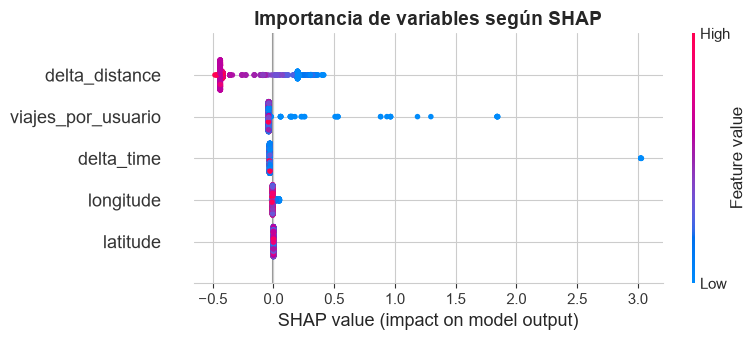

💾 Outliers con SHAP guardados en: sin_timestamp_hora_frecuencia_id_velocidad_con_shap.csv
📄 El CSV tiene 579 filas.


In [48]:
# =============================================
# 1. Cargar datos y seleccionar la mejor combinación
# =============================================
X_best = iso_forest_data[feature_sets[best_name]]
total_rows = len(X_best)
print(f"📊 Total de registros: {total_rows:,}")

# =============================================
# 2. Ejecutar Isolation Forest (con tus 0.0001 outliers)
# =============================================
PROPORCION_OUTLIERS = 0.0001
n_outliers = int(PROPORCION_OUTLIERS * total_rows)
result_best = run_isolation_forest(X_best, n_outliers=n_outliers, return_pipeline=True)  # Ajusta a 1000
model = result_best['pipeline'].named_steps['iso_forest']
outlier_indices = result_best['outlier_indices']
inlier_indices = np.where(result_best['labels'] == 1)[0]

print(f"🔍 Outliers encontrados: {len(outlier_indices)}")
print(f"✅ Inliers disponibles: {len(inlier_indices):,}")

# =============================================
# 3. Construir muestra balanceada para SHAP (MÁXIMO 2000 FILAS)
# =============================================
MAX_SHAP_SAMPLES = int(0.0002*total_rows)  # Tope duro por rendimiento

# Como tienes 1000 outliers, cogeremos exactamente 1000 inliers (balance 50%-50%)
n_inliers_a_coger = MAX_SHAP_SAMPLES - len(outlier_indices)

if n_inliers_a_coger > 0:
    sampled_inliers = np.random.choice(inlier_indices,
                                       size=min(n_inliers_a_coger, len(inlier_indices)),
                                       replace=False)
    selected_indices = np.concatenate([outlier_indices, sampled_inliers])
else:
    # Esto solo pasaría si tuvieras más de 2000 outliers (no es tu caso)
    selected_indices = np.random.choice(outlier_indices, size=MAX_SHAP_SAMPLES, replace=False)

np.random.shuffle(selected_indices)
X_sample = X_best.iloc[selected_indices]
print(f"✅ Muestra final para SHAP: {len(X_sample)} filas ({len(outlier_indices)} outliers + {len(X_sample)-len(outlier_indices)} inliers)")

# =============================================
# 4. Background (200 filas aleatorias es más que suficiente)
# =============================================
background_sample = X_best.sample(n=min(200, len(X_best)), random_state=42)

# =============================================
# 5. Explicador SHAP (MODO RÁPIDO, sin "interventional")
# =============================================
explainer = shap.TreeExplainer(model, data=background_sample)  # Modo tree_path_dependent (rápido)

# =============================================
# 6. Calcular SHAP UNA SOLA VEZ (sobre las 2000 filas)
# =============================================
shap_values = explainer.shap_values(X_sample)

# =============================================
# 7. VISUALIZACIONES (esto abre ventanas interactivas)
# =============================================
shap.summary_plot(shap_values, X_sample, feature_names=X_best.columns, show=False)

plt.title('Importancia de variables según SHAP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# =============================================
# 8. Extraer SOLO los outliers para el CSV (sin recalcular)
# =============================================
# Búsqueda rápida en vector (mucho más rápido que list comprehension)
outlier_positions = np.where(np.isin(selected_indices, outlier_indices))[0]
shap_values_outliers = shap_values[outlier_positions]

# =============================================
# 9. Guardar CSV con los 1000 outliers y sus SHAP values
# =============================================
shap_df = pd.DataFrame(shap_values_outliers, columns=[f"shap_{col}" for col in X_best.columns])
outliers_df = iso_forest_data.iloc[outlier_indices].reset_index(drop=True)
final_df = pd.concat([outliers_df, shap_df], axis=1)
final_df['expected_value'] = explainer.expected_value

shap_filename = f"{best_name}_con_shap.csv"
final_df.to_csv(shap_filename, index=False)
print(f"💾 Outliers con SHAP guardados en: {shap_filename}")
print(f"📄 El CSV tiene {len(final_df)} filas.")

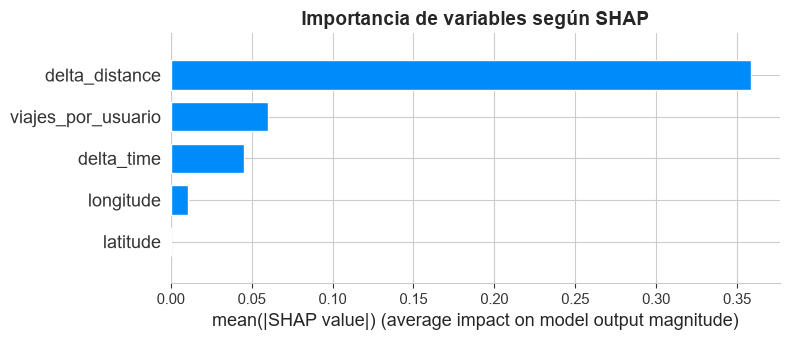

In [49]:
shap.summary_plot(shap_values, X_sample, feature_names=X_best.columns,
                  plot_type="bar", max_display=10, show=False)
plt.title('Importancia de variables según SHAP', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

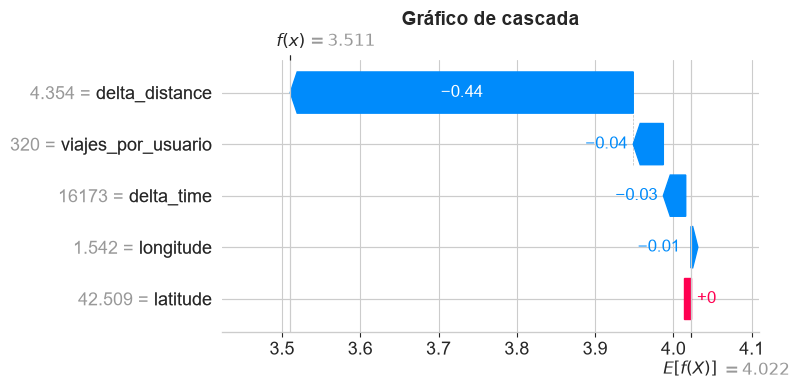

In [50]:
# El outlier más extremo es el que tiene el score más bajo (primer índice de outlier_indices)
scores = result_best['scores']
idx_extremo_original = outlier_indices[np.argmin(scores[outlier_indices])]
pos_extremo = np.where(selected_indices == idx_extremo_original)[0][0]

explanation = shap.Explanation(values=shap_values[pos_extremo],
                               base_values=explainer.expected_value,
                               data=X_sample.iloc[pos_extremo].values,
                               feature_names=X_best.columns)
shap.waterfall_plot(explanation, max_display=10, show=False)
plt.title('Gráfico de cascada', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Variable más importante: delta_distance


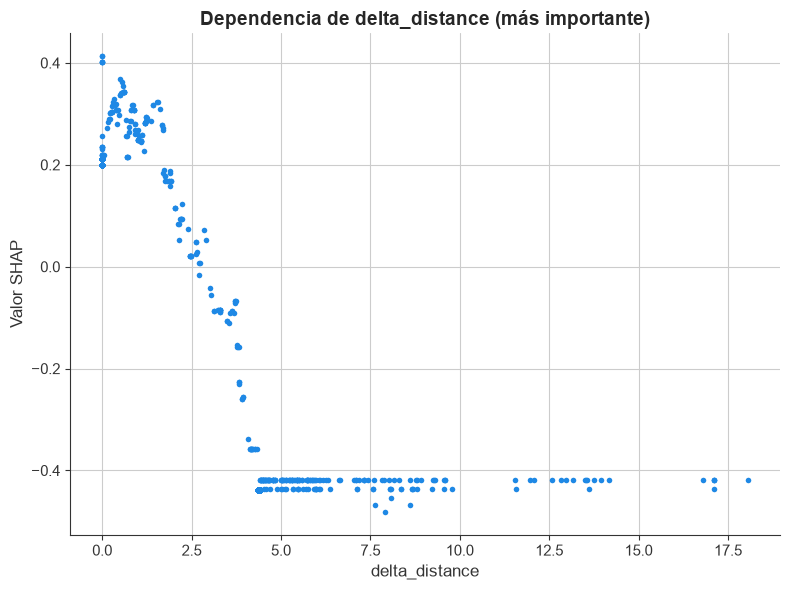

In [51]:
# 1. Calcular la importancia media absoluta de SHAP
# Asume que shap_values es un array (n_muestras, n_características)
mean_abs_shap = np.abs(shap_values).mean(axis=0)   # si es numpy array
# Si shap_values es un objeto Explanation de SHAP:
# mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# 2. Seleccionar la variable con mayor importancia
var = X_best.columns[np.argmax(mean_abs_shap)]
print(f"Variable más importante: {var}")

# 3. Crear figura y dependence plot
fig, ax = plt.subplots(figsize=(8, 6))
shap.dependence_plot(
    var,
    shap_values,
    X_sample,
    feature_names=X_best.columns,
    interaction_index=None,
    ax=ax,
    show=False
)

# 4. Estilo
ax.set_title(f'Dependencia de {var} (más importante)', fontsize=14, fontweight='bold')
ax.set_xlabel(var, fontsize=12)
ax.set_ylabel('Valor SHAP', fontsize=12)

plt.tight_layout()
plt.savefig('shap_dependence_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Boxplot

In [52]:
# 1. Crear DataFrames separados para cada grupo
df_outliers = X_best.iloc[outlier_indices].copy()
df_inliers = X_best.iloc[inlier_indices].copy()

# 2. Para "Todos", cogemos una muestra aleatoria del 10% (o 10,000 filas)
#    para no petar la memoria al graficar.
sample_size_all = min(10000, len(X_best))  # Muestra aleatoria de 10k
df_all = X_best.sample(n=sample_size_all, random_state=42).copy()

# Asignamos una columna de grupo a cada uno para facilitar el plot unificado
df_outliers['Grupo'] = 'Outlier'
df_inliers['Grupo'] = 'Inlier'
df_all['Grupo'] = 'Todos (Muestra)'

# Unimos todo en un solo DataFrame para usar con seaborn (opcional)
df_plot_unificado = pd.concat([df_outliers, df_inliers, df_all], axis=0, ignore_index=True)

print(f"📊 Outliers: {len(df_outliers)} | Inliers: {len(df_inliers)} | Todos (muestra): {len(df_all)}")

📊 Outliers: 579 | Inliers: 5796297 | Todos (muestra): 10000


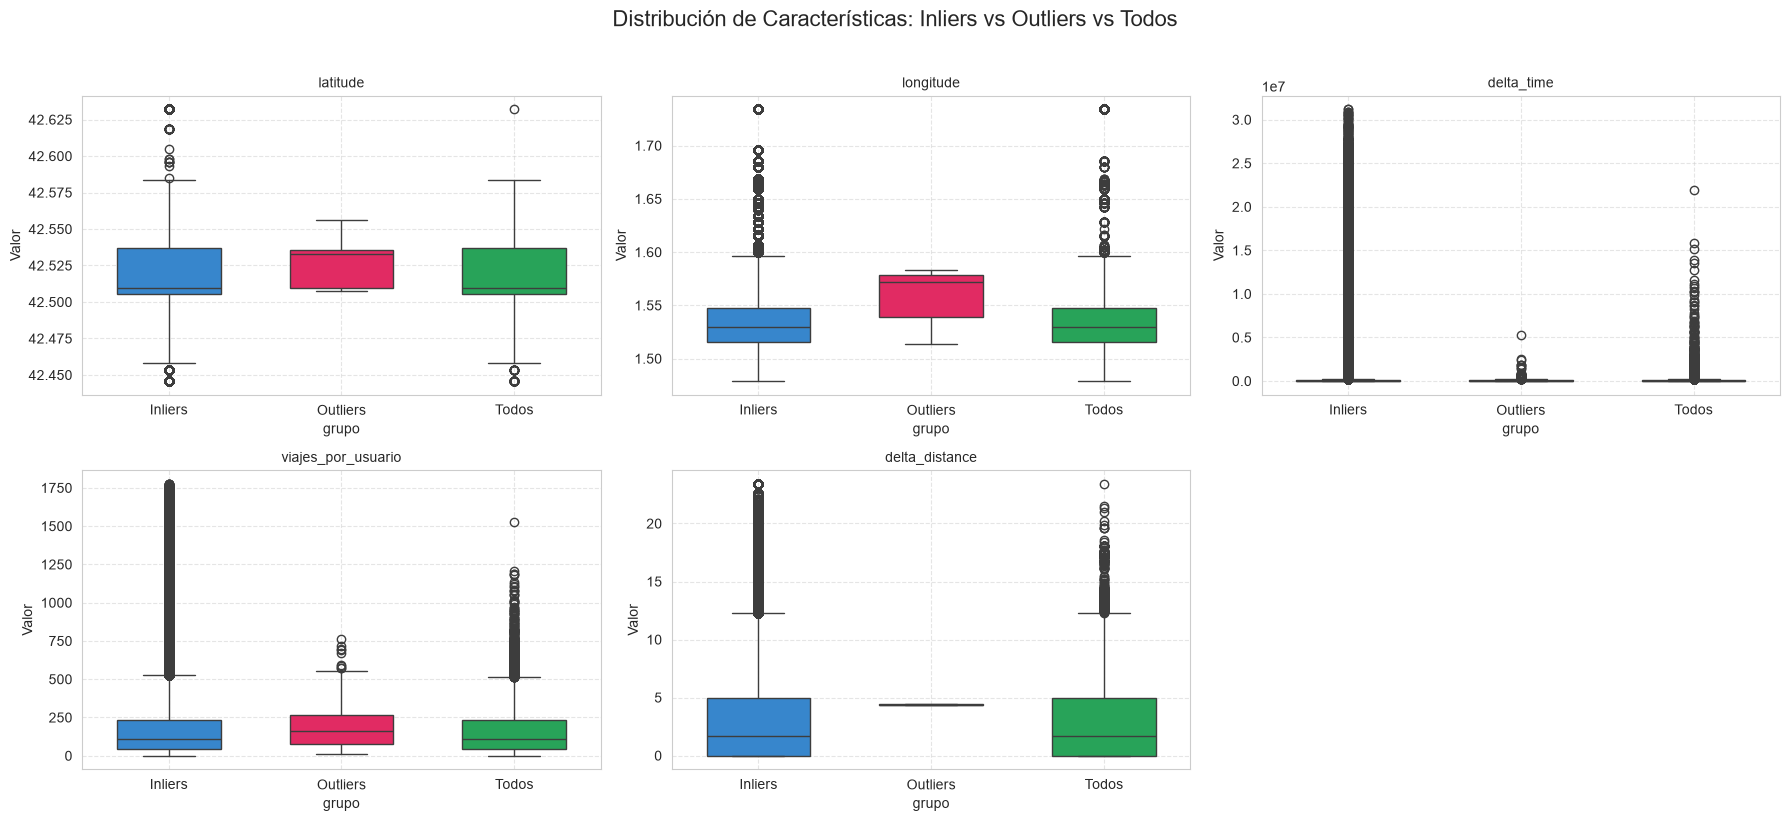

In [53]:
# Preparar datos: necesitamos un DataFrame largo con una columna 'grupo'
# Para cada característica, creamos un DataFrame con los valores y el grupo
dfs = []
for col in X_best.columns:
    # Extraer valores de cada grupo (sin NaN)
    in_vals = df_inliers[col].dropna().values
    out_vals = df_outliers[col].dropna().values
    all_vals = df_all[col].dropna().values
    
    # Crear DataFrame para esta característica
    temp = pd.DataFrame({
        'valor': np.concatenate([in_vals, out_vals, all_vals]),
        'grupo': ['Inliers']*len(in_vals) + ['Outliers']*len(out_vals) + ['Todos']*len(all_vals),
        'feature': col
    })
    dfs.append(temp)

df_long = pd.concat(dfs, ignore_index=True)

# Configurar la cuadrícula
n_features = X_best.shape[1]
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
fig.suptitle('Distribución de Características: Inliers vs Outliers vs Todos', fontsize=16, y=1.02)

# Aplanar ejes
axes_flat = axes.flatten()

for i, col in enumerate(X_best.columns):
    ax = axes_flat[i]
    # Filtrar datos de esta característica
    data_col = df_long[df_long['feature'] == col]
    
    # Boxplot con seaborn (todos del mismo color teal)
    sns.boxplot(data=data_col, x='grupo', y='valor', 
                palette=graph_palette[:3],  # <--- Color uniforme
                ax=ax, width=0.6, hue='grupo', legend=False)
    
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Valor')
    ax.grid(True, linestyle='--', alpha=0.5)

# Ocultar ejes vacíos
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

### Comprovación de fraude

In [54]:
fraud_in_outliers = [idx for idx in fraud_idx if idx in df_outliers.index]
print(f"Fraudes en outliers: {len(fraud_in_outliers)} de {len(fraud_idx)}")

Fraudes en outliers: 0 de 7


## Autoencoder

### Datos

In [55]:
auto_encoder_data = df_val_par.drop('coord_imputada', axis=1)

In [56]:
configs = [
    # 1. Baseline (la que tú tienes)
    {
        'name': 'Baseline_64_32',
        'encoder_units': [64, 32],
        'latent_dim': 10,
        'activation': 'relu',
        'dropout': None,
        'l2_reg': None,
        'lr': 1e-3
    },
    # 2. Más ancha
    {
        'name': 'Wider_128_64',
        'encoder_units': [128, 64],
        'latent_dim': 10,
        'activation': 'relu',
        'dropout': None,
        'l2_reg': None,
        'lr': 1e-3
    },
    # 3. Más profunda
    {
        'name': 'Deeper_128_64_32',
        'encoder_units': [128, 64, 32],
        'latent_dim': 10,
        'activation': 'relu',
        'dropout': None,
        'l2_reg': None,
        'lr': 1e-3
    },
    # 4. Latente más pequeño (mayor compresión)
    {
        'name': 'Small_Latent_5',
        'encoder_units': [64, 32],
        'latent_dim': 5,
        'activation': 'relu',
        'dropout': None,
        'l2_reg': None,
        'lr': 1e-3
    },
    # 5. Latente más grande (menos compresión)
    {
        'name': 'Large_Latent_20',
        'encoder_units': [64, 32],
        'latent_dim': 20,
        'activation': 'relu',
        'dropout': None,
        'l2_reg': None,
        'lr': 1e-3
    },
    # 6. Activación SELU (auto-normalizante)
    {
        'name': 'SELU_64_32',
        'encoder_units': [64, 32],
        'latent_dim': 10,
        'activation': 'selu',
        'dropout': None,
        'l2_reg': None,
        'lr': 1e-3
    },
    # 7. Con Dropout (regularización)
    {
        'name': 'Dropout_0.2',
        'encoder_units': [64, 32],
        'latent_dim': 10,
        'activation': 'relu',
        'dropout': 0.2,
        'l2_reg': None,
        'lr': 1e-3
    },
    # 8. Con L2 Regularization
    {
        'name': 'L2_1e-4',
        'encoder_units': [64, 32],
        'latent_dim': 10,
        'activation': 'relu',
        'dropout': None,
        'l2_reg': 1e-4,
        'lr': 1e-3
    },
    # 9. Learning Rate más bajo (entrenamiento más estable)
    {
        'name': 'LR_1e-4',
        'encoder_units': [64, 32],
        'latent_dim': 10,
        'activation': 'relu',
        'dropout': None,
        'l2_reg': None,
        'lr': 1e-4
    }
]

### Entrenamiento

In [57]:
def build_autoencoder(input_dim, config):
    # --- ENCODER ---
    encoder_inputs = layers.Input(shape=(input_dim,), name="input")
    x = encoder_inputs
    
    for i, units in enumerate(config['encoder_units']):
        # Dropout (si está definido)
        if config.get('dropout') and i > 0:  # Normalmente no se pone dropout en la primera capa
            x = layers.Dropout(config['dropout'])(x)
        
        # Capa densa con regularización L2 (si está definida)
        if config.get('l2_reg'):
            x = layers.Dense(units, activation=config['activation'],
                             kernel_regularizer=regularizers.l2(config['l2_reg']),
                             name=f"enc_{i}")(x)
        else:
            x = layers.Dense(units, activation=config['activation'], name=f"enc_{i}")(x)
    
    # Capa latente
    latent = layers.Dense(config['latent_dim'], activation=config['activation'], name="latent")(x)
    encoder = models.Model(encoder_inputs, latent, name="Encoder")
    
    # --- DECODER (simétrico) ---
    decoder_inputs = layers.Input(shape=(config['latent_dim'],), name="decoder_input")
    y = decoder_inputs
    
    # Invertimos la lista de unidades del encoder
    for i, units in enumerate(reversed(config['encoder_units'])):
        if config.get('dropout') and i > 0:
            y = layers.Dropout(config['dropout'])(y)
        
        if config.get('l2_reg'):
            y = layers.Dense(units, activation=config['activation'],
                             kernel_regularizer=regularizers.l2(config['l2_reg']),
                             name=f"dec_{i}")(y)
        else:
            y = layers.Dense(units, activation=config['activation'], name=f"dec_{i}")(y)
    
    # Capa de salida (usamos sigmoid porque los datos están normalizados en [0,1])
    outputs = layers.Dense(input_dim, activation='sigmoid', name="reconstruction")(y)
    decoder = models.Model(decoder_inputs, outputs, name="Decoder")
    
    # --- AUTOENCODER COMPLETO ---
    autoencoder = models.Model(encoder_inputs, decoder(encoder(encoder_inputs)), name="Autoencoder")
    
    return autoencoder, encoder, decoder

In [58]:
def train_and_evaluate_unsupervised(config, X_train, X_val, epochs=100, batch_size=256):
    input_dim = X_train.shape[1]
    
    # Construir modelo
    ae, enc, dec = build_autoencoder(input_dim, config)
    
    # Compilar (¡corregido con tf.keras!)
    ae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config.get('lr', 1e-3)),
               loss='mse')
    
    # Early stopping para evitar sobreajuste
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    # Entrenar
    history = ae.fit(X_train, X_train,
                     validation_data=(X_val, X_val),
                     epochs=epochs,
                     batch_size=batch_size,
                     callbacks=[early_stop],
                     verbose=0)  # Pon 1 si quieres ver el progreso
    
    # --- Reconstrucciones y errores ---
    train_recon = ae.predict(X_train, verbose=0)
    val_recon = ae.predict(X_val, verbose=0)
    
    train_errors = np.mean((X_train - train_recon)**2, axis=1)
    val_errors = np.mean((X_val - val_recon)**2, axis=1)
    
    # --- Definir umbral (percentil 99.9 en validación) ---
    threshold = np.percentile(val_errors, 99.9)
    
    # --- Clasificar puntos en validación (para calcular métricas) ---
    is_anomaly_val = (val_errors > threshold).astype(int)
    
    errors_anomalies = val_errors[is_anomaly_val == 1]
    errors_normals = val_errors[is_anomaly_val == 0]
    
    # --- Calcular métricas intrínsecas ---
    metrics = {
        'name': config['name'],
        'latent_dim': config['latent_dim'],
        'n_params': ae.count_params(),
        'train_loss_min': np.min(history.history['loss']),
        'val_loss_min': np.min(history.history['val_loss']),
        'threshold_999': threshold,
        'anomaly_ratio': np.mean(is_anomaly_val),
        'kurtosis': pd.Series(val_errors).kurtosis(),
        'gap': (np.mean(val_errors) - np.median(val_errors)) / (np.std(val_errors) + 1e-9),
        'mean_error_anomaly': np.mean(errors_anomalies) if len(errors_anomalies) > 0 else np.nan,
        'mean_error_normal': np.mean(errors_normals) if len(errors_normals) > 0 else np.nan,
        'separation': np.mean(errors_normals) - np.mean(errors_anomalies)  # Normal debe ser menor
    }
    
    return metrics, ae, history

In [ ]:
# --- 1. Preparar los datos (submuestra del 10-20% si son 6M) ---
print("Preparando datos...")
# Si quieres usar una submuestra representativa (recomendado)
X_sample = auto_encoder_data.sample(frac=0.10, random_state=42)  # 10% de 6M = 600k
print(f"Usando {len(X_sample)} registros para el experimento")

# Dividir en train (80%) y validation (20%), ambos sin etiquetas
X_train, X_val = train_test_split(X_sample, test_size=0.2, random_state=42)
# Ajustar scaler en entrenamiento para evitar data leakage
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)  # ¡Solo transformar, no fit!
print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}")

# --- 2. Iterar sobre las configuraciones ---
results = []

for config in configs:
    print(f"\n🚀 Entrenando configuración: {config['name']}")
    print(f"   Unidades: {config['encoder_units']}, Latente: {config['latent_dim']}, Activación: {config['activation']}")
    
    metrics, model, hist = train_and_evaluate_unsupervised(
        config, X_train_scaled, X_val_scaled,
        epochs=100,          # Puedes aumentar si ves que mejora
        batch_size=256
    )
    
    results.append(metrics)
    
    # Imprimir métricas clave
    print(f"   ✅ Val Loss: {metrics['val_loss_min']:.6f}")
    print(f"   📊 Kurtosis: {metrics['kurtosis']:.3f}")
    print(f"   📊 Gap: {metrics['gap']:.3f}")
    print(f"   📊 Separation: {metrics['separation']:.6f}")
    print(f"   🧊 Anomaly Ratio (99.9%): {metrics['anomaly_ratio']*100:.2f}%")

# --- 3. Convertir a DataFrame y ordenar ---
df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("RESULTADOS COMPARATIVOS")
print("="*80)
print(df_results[['name', 'val_loss_min', 'kurtosis', 'gap', 'separation', 'anomaly_ratio']])

Preparando datos...
Usando 579688 registros para el experimento
Train: (463750, 20), Val: (115938, 20)

🚀 Entrenando configuración: Baseline_64_32
   Unidades: [64, 32], Latente: 10, Activación: relu
   ✅ Val Loss: 0.003212
   📊 Kurtosis: 32.843
   📊 Gap: 0.256
   📊 Separation: -0.034777
   🧊 Anomaly Ratio (99.9%): 0.10%

🚀 Entrenando configuración: Wider_128_64
   Unidades: [128, 64], Latente: 10, Activación: relu
   ✅ Val Loss: 0.001248
   📊 Kurtosis: 136.129
   📊 Gap: 0.220
   📊 Separation: -0.034612
   🧊 Anomaly Ratio (99.9%): 0.10%

🚀 Entrenando configuración: Deeper_128_64_32
   Unidades: [128, 64, 32], Latente: 10, Activación: relu
   ✅ Val Loss: 0.002182
   📊 Kurtosis: 96.117
   📊 Gap: 0.222
   📊 Separation: -0.038907
   🧊 Anomaly Ratio (99.9%): 0.10%

🚀 Entrenando configuración: Small_Latent_5
   Unidades: [64, 32], Latente: 5, Activación: relu


In [ ]:
# Normalizar métricas (a mayor valor, mejor)
df_norm = df_results.copy()
for col in ['separation', 'kurtosis', 'gap']:
    df_norm[col] = (df_norm[col] - df_norm[col].min()) / (df_norm[col].max() - df_norm[col].min() + 1e-9)

# Invertir val_loss (menor es mejor)
df_norm['val_loss_min'] = 1 - (df_norm['val_loss_min'] - df_norm['val_loss_min'].min()) / (df_norm['val_loss_min'].max() - df_norm['val_loss_min'].min() + 1e-9)

# Ponderación
weights = {'separation': 0.4, 'kurtosis': 0.3, 'gap': 0.2, 'val_loss_min': 0.1}
df_norm['score'] = sum(df_norm[col] * weight for col, weight in weights.items())
df_results['score'] = df_norm['score']

best_config = df_results.loc[df_results['score'].idxmax()]
print("\n🏆 MEJOR CONFIGURACIÓN SEGÚN PUNTUACIÓN COMPUESTA:")
print(best_config[['name', 'score', 'separation', 'kurtosis', 'gap', 'val_loss_min']])


🏆 MEJOR CONFIGURACIÓN SEGÚN PUNTUACIÓN COMPUESTA:
name            Large_Latent_20
score                  0.793974
separation            -0.002457
kurtosis               53.01664
gap                    0.289692
val_loss_min           0.000285
Name: 4, dtype: object


### Curva de aprendizaje

In [ ]:
config_best = configs[[cfg['name'] for cfg in configs].index(best_config['name'])]
input_dim = X_train_scaled.shape[1]

ae_best, enc, dec = build_autoencoder(input_dim, config_best)
ae_best.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config_best['lr']),
                loss='mse')

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entrenar y guardar historial
history_best = ae_best.fit(X_train_scaled, X_train_scaled,
                           validation_data=(X_val_scaled, X_val_scaled),
                           epochs=100,
                           batch_size=256,
                           callbacks=[early_stop],
                           verbose=1)   # Para ver el progreso

Epoch 1/100
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - loss: 0.0099 - val_loss: 0.0023
Epoch 2/100
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0016 - val_loss: 0.0012
Epoch 3/100
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0011 - val_loss: 9.8867e-04
Epoch 4/100
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 8.8066e-04 - val_loss: 8.3471e-04
Epoch 5/100
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 7.3628e-04 - val_loss: 7.8950e-04
Epoch 6/100
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 6.6973e-04 - val_loss: 6.2860e-04
Epoch 7/100
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 5.9489e-04 - val_loss: 5.4319e-04
Epoch 8/100
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 5.1388e-04 - val_loss: 4.8103e-04
Epoch 9/100
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 4.8488e-04 - val_loss: 4.7851e-04
Epoch 10/100
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 4.6696e-04 - val_loss: 4.3786e-04
Epoch 11/100
1812/1812 ━━━━━━━━━━━━━━━━━━━━ 8s

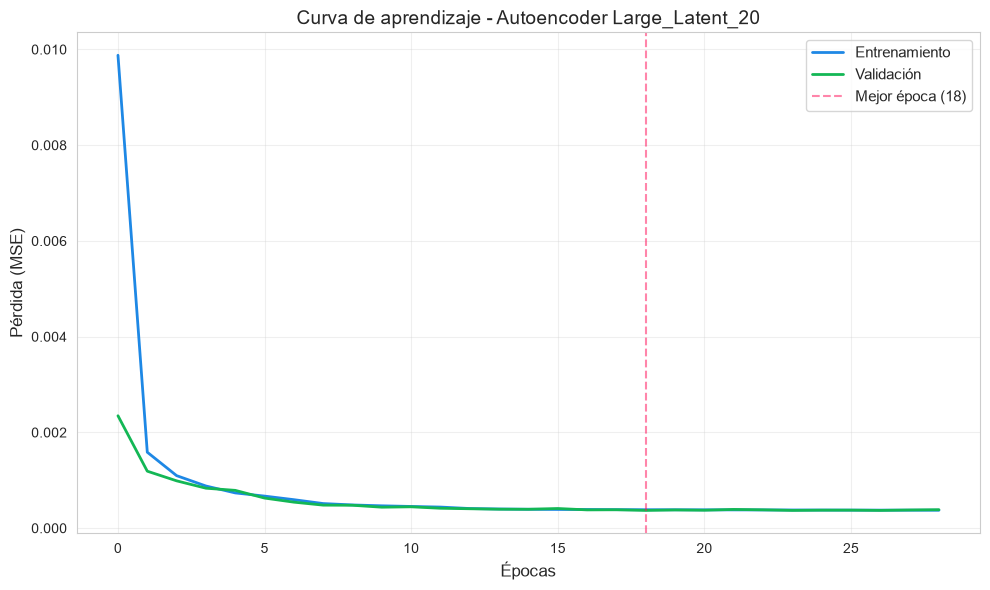

In [ ]:
# Estilo seaborn para un fondo limpio
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

# Extraer colores de la paleta (si es una lista de strings hex o colores RGB)
color_train = graph_palette[0]
color_val = graph_palette[2]
color_best_epoch = graph_palette[1]

# Curvas de pérdida
plt.plot(history_best.history['loss'], label='Entrenamiento', 
         color=color_train, linewidth=2)
plt.plot(history_best.history['val_loss'], label='Validación', 
         color=color_val, linewidth=2)

# Mejor época (early stopping)
best_epoch = np.argmin(history_best.history['val_loss'])
plt.axvline(x=best_epoch, color=color_best_epoch, linestyle='--', alpha=0.5, 
            label=f'Mejor época ({best_epoch})')

# Etiquetas y formato
plt.xlabel('Épocas', fontsize=12)
plt.ylabel('Pérdida (MSE)', fontsize=12)
plt.title('Curva de aprendizaje - Autoencoder Large_Latent_20', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('learning_curve_ae.png', dpi=300, bbox_inches='tight')
plt.show()

### Error medio por variable

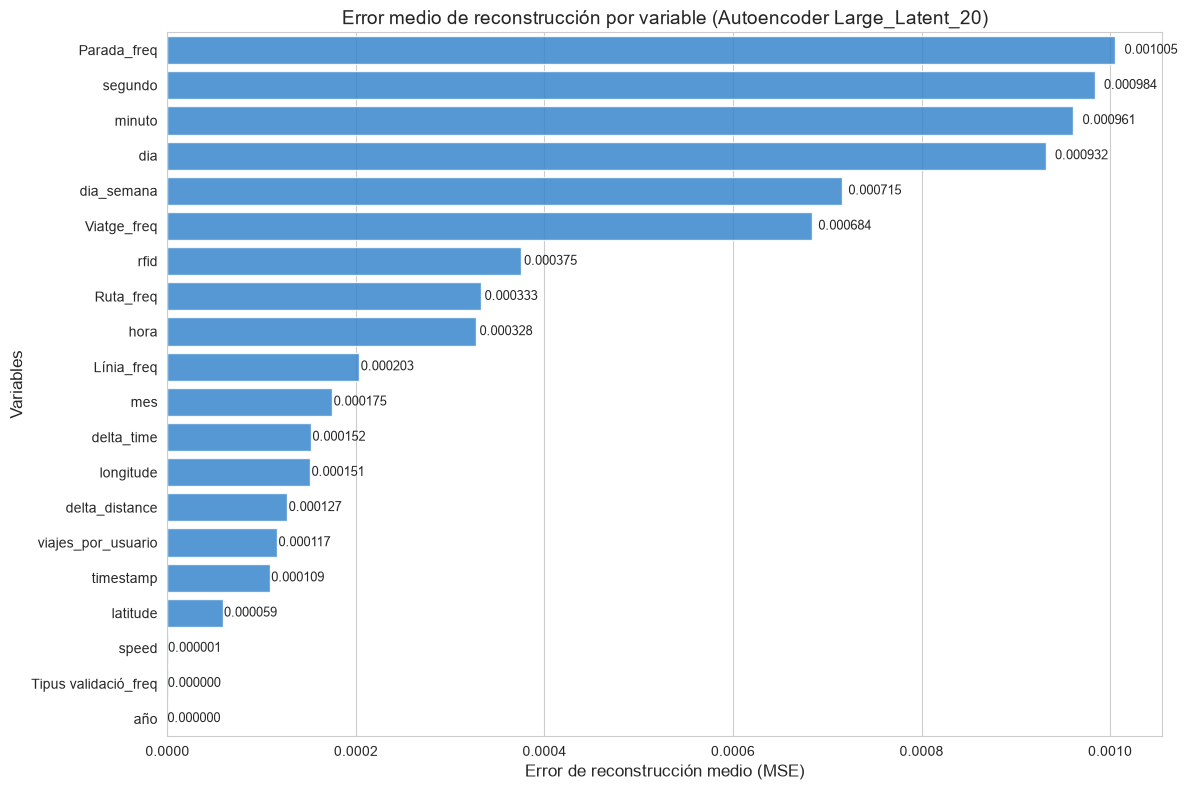

In [ ]:
# 1. Obtener las reconstrucciones para el conjunto de validación
X_val_recon = ae_best.predict(X_val_scaled, verbose=0)

# 2. Calcular el error cuadrático medio (MSE) por variable (columna)
# Esto te da un array de tamaño (n_features,)
variable_errors = np.mean((X_val_scaled - X_val_recon) ** 2, axis=0)

# 3. Crear un DataFrame para graficar fácilmente con Seaborn
# Si X_best es un DataFrame, usa sus columnas. Si no, crea nombres genéricos.
if hasattr(auto_encoder_data, 'columns'):
    feature_names = auto_encoder_data.columns
else:
    feature_names = [f'Variable_{i+1}' for i in range(len(variable_errors))]

df_errors = pd.DataFrame({
    'Variable': feature_names,
    'MSE': variable_errors
})

# 4. Ordenar de mayor a menor error (para visualizar mejor la cola)
df_errors = df_errors.sort_values('MSE', ascending=False).reset_index(drop=True)

# 5. Graficar con Seaborn (usando tu paleta)
# Elegimos el primer color de la paleta para todas las barras,
# o puedes usar un gradiente de colores si prefieres.
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Crear el gráfico de barras horizontales (mejor para leer nombres largos)
bars = sns.barplot(data=df_errors, y='Variable', x='MSE', 
                   color=graph_palette[0],  # Usa el color principal de tu paleta
                   alpha=0.85)

# Añadir etiquetas con el valor numérico al final de cada barra (opcional)
for i, v in enumerate(df_errors['MSE']):
    bars.text(v + (v * 0.01), i, f'{v:.6f}', va='center', fontsize=9)

# Formato y etiquetas
plt.xlabel('Error de reconstrucción medio (MSE)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.title('Error medio de reconstrucción por variable (Autoencoder Large_Latent_20)', 
          fontsize=14)
plt.tight_layout()
plt.savefig('variable_errors_ae.png', dpi=300, bbox_inches='tight')
plt.show()

### Histograma

Umbral (percentil 99.99): 0.003545


C:\Users\poshiro\AppData\Local\Temp\ipykernel_4424\2019921758.py:23: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.histplot(data=df_hist, x='Error', hue='Tipo',


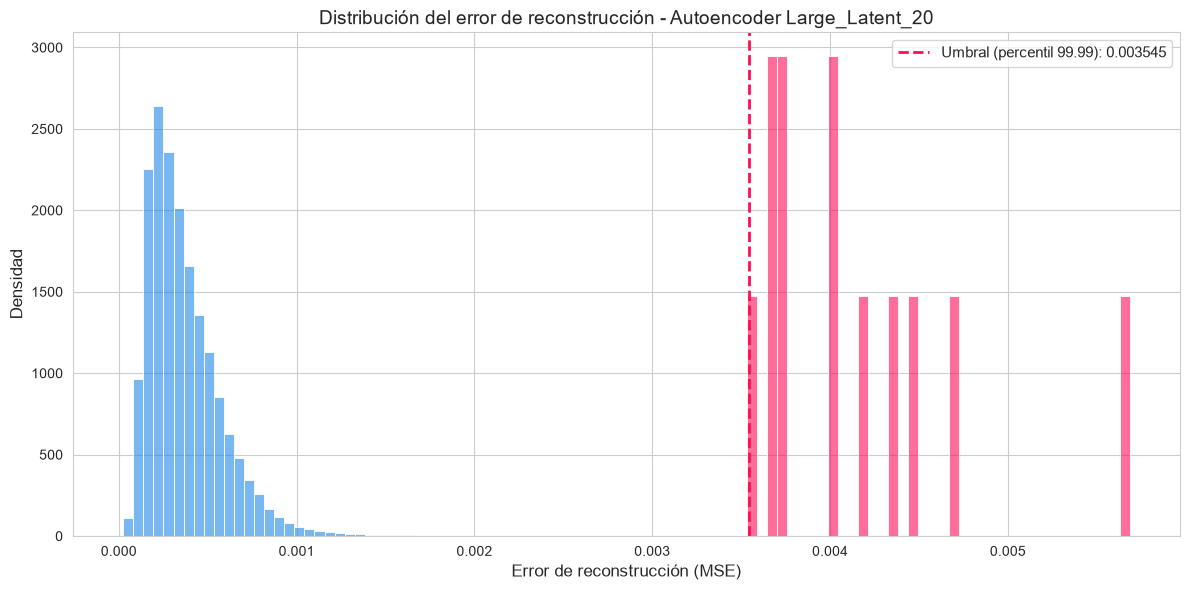

In [ ]:
# Obtener las reconstrucciones para el conjunto de validación
X_val_recon = ae_best.predict(X_val_scaled, verbose=0)

# Calcular el error cuadrático medio (MSE) por muestra
# Esto te da un array de tamaño (n_val_samples,)
val_errors = np.mean((X_val_scaled - X_val_recon) ** 2, axis=1)

threshold = np.percentile(val_errors, 99.99)
print(f"Umbral (percentil 99.99): {threshold:.6f}")

# Crear un DataFrame para facilitar el coloreado
df_hist = pd.DataFrame({
    'Error': val_errors,
    'Tipo': np.where(val_errors > threshold, 'Potencial fraude', 'Normal')
})

# Estilo
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Histograma con seaborn, diferenciando por color según el umbral
# Usamos hue para separar los dos grupos y la paleta para asignar colores
sns.histplot(data=df_hist, x='Error', hue='Tipo', 
             bins=100,                # Número de barras (ajusta según necesidad)
             palette=graph_palette,   # Usa tu paleta (debe tener al menos 2 colores)
             alpha=0.6,              # Transparencia para ver solapamiento
             element='bars',         # Barras sólidas
             stat='density',         # Normaliza el área a 1 (mejor para comparar)
             common_norm=False)      # Cada grupo se normaliza por separado

# Línea vertical para el umbral
plt.axvline(x=threshold, color=graph_palette[1], linestyle='--', linewidth=2, 
            label=f'Umbral (percentil 99.99): {threshold:.6f}')

# Etiquetas y formato
plt.xlabel('Error de reconstrucción (MSE)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.title('Distribución del error de reconstrucción - Autoencoder Large_Latent_20', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('error_histogram_ae.png', dpi=300, bbox_inches='tight')
plt.show()

### Boxplot

C:\Users\poshiro\AppData\Local\Temp\ipykernel_4424\294743575.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_hist, x='Tipo', y='Error',
C:\Users\poshiro\AppData\Local\Temp\ipykernel_4424\294743575.py:7: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  ax = sns.boxplot(data=df_hist, x='Tipo', y='Error',


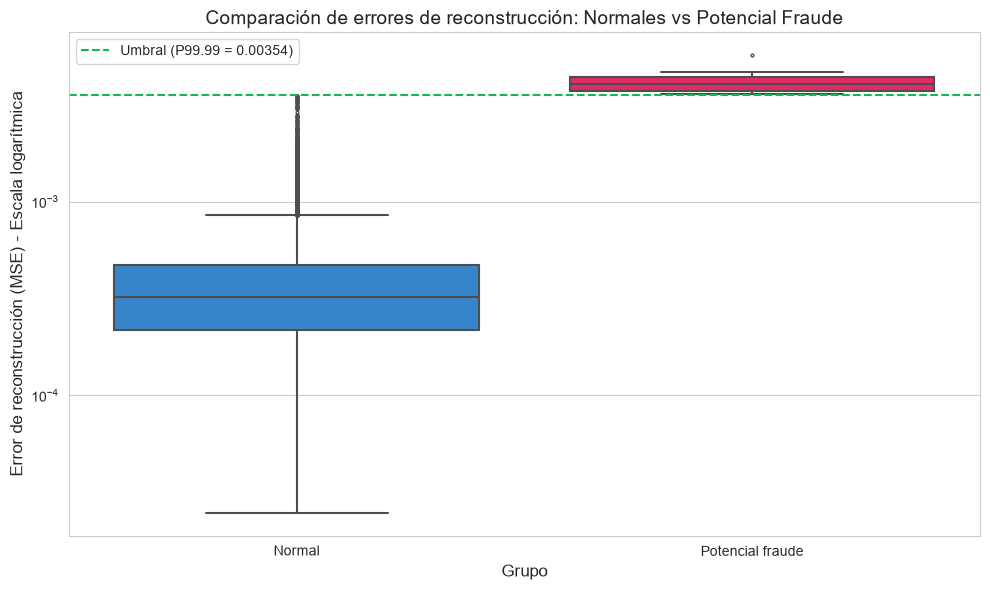

In [ ]:
# Estilo
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Crear el boxplot
# Usamos palette=graph_palette para mantener la coherencia
ax = sns.boxplot(data=df_hist, x='Tipo', y='Error', 
                 palette=graph_palette, 
                 showfliers=True,        # Mostrar outliers (puntos)
                 fliersize=2,            # Tamaño de los puntos outliers
                 linewidth=1.5)          # Grosor de las líneas

# --- OPCIÓN 1: Escala logarítmica (MUY RECOMENDADA) ---
# Descomenta esta línea para ver mejor la distribución
plt.yscale('log')

# Línea horizontal para el umbral (opcional, pero ilustrativo)
# threshold = np.percentile(val_errors, 99.9)  # Si no lo tienes definido
plt.axhline(y=threshold, color=graph_palette[2], linestyle='--', linewidth=1.5, 
            label=f'Umbral (P99.99 = {threshold:.5f})')

# Etiquetas y formato
plt.xlabel('Grupo', fontsize=12)
plt.ylabel('Error de reconstrucción (MSE) - Escala logarítmica', fontsize=12)
plt.title('Comparación de errores de reconstrucción: Normales vs Potencial Fraude', fontsize=14)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('boxplot_errors_ae.png', dpi=300, bbox_inches='tight')
plt.show()

### Comprovación de fraude

In [ ]:
# Extraer los 7 casos de fraude
fraud_dataset = auto_encoder_data.loc[fraud_idx].copy()
print(f"Dataset de evaluación: {len(fraud_dataset)} filas")

# Escalar los datos con el mismo scaler que usaste en el entrenamiento (si usaste MinMaxScaler)
# Suponiendo que tienes 'scaler' de tu entrenamiento del AE
eval_scaled = scaler.transform(fraud_dataset)  # Eliminar columna de etiqueta

# Reconstruir con el autoencoder (ae_best)
recon_ae = ae_best.predict(eval_scaled, verbose=0)
errors_ae = np.mean((eval_scaled - recon_ae) ** 2, axis=1)

# Clasificar usando el umbral (threshold_ae que calculaste antes)
pred_ae = errors_ae > threshold

# Añadir resultados al dataset
fraud_dataset['Error_AE'] = errors_ae
fraud_dataset['Prediccion_AE'] = pred_ae
n_detectados_ae = fraud_dataset['Prediccion_AE'].sum()
total = len(fraud_dataset)
print(f"Fraudes detectados por el autoencoder: {n_detectados_ae} de {total} ({n_detectados_ae/total*100:.1f}%)")

Dataset de evaluación: 7 filas
Fraudes detectados por el autoencoder: 6 de 7 (85.7%)


## RBM

### Datos

In [ ]:
rbm_data = df_val_par.drop('coord_imputada', axis=1)

# muestreo
muestra_size = 50000
np.random.seed(42)
indices_muestra = np.random.choice(len(rbm_data), muestra_size, replace=False)
rbm_data_subset = rbm_data.iloc[indices_muestra]

# Separación del conjunto de entrenamiento y validación (80%-20%)
X_train_rbm, X_val_rbm = train_test_split(rbm_data_subset, test_size=0.2, random_state=42)

# Escalamos los datos
rbm_scaler = MinMaxScaler()
X_train_rbm_scaled = rbm_scaler.fit_transform(X_train_rbm)
X_val_rbm_scaled = rbm_scaler.transform(X_val_rbm)
n_train = X_train_rbm_scaled.shape[0]
n_val = X_val_rbm_scaled.shape[0]

### Entrenamiento

In [ ]:
# RBM
class RBMWithScorer(BernoulliRBM):
    def score(self, X, y=None):
        """
        Calcula la separación entre outliers e inliers basado en el error de reconstrucción.
        Retorna un valor positivo (outliers - inliers) para que GridSearch lo maximice.
        """
        # 1. Obtener reconstrucción
        hidden = self.transform(X)
        def sigmoid(z):
            return 1 / (1 + np.exp(-z))
        reconstruction = sigmoid(np.dot(hidden, self.components_) + self.intercept_visible_)
        # 2. Error MSE por muestra
        errors = np.mean((X - reconstruction) ** 2, axis=1)
        # 3. Umbral (percentil 99.9)
        threshold = np.percentile(errors, 99.9)
        outliers = errors > threshold
        inliers = ~outliers
        # 4. Separación (positiva: cuanto mayor, mejor separación)
        if np.sum(outliers) == 0 or np.sum(inliers) == 0:
            return -np.inf  # castigo si no hay outliers o inliers
        return np.mean(errors[outliers]) - np.mean(errors[inliers])

In [ ]:
# Preparar para PredefinedSplit
train_idx = X_train_rbm.index.values
val_idx = X_val_rbm.index.values

# Combinar datos para GridSearch
X_combined = np.vstack([X_train_rbm_scaled, X_val_rbm_scaled])
test_fold_concat = np.concatenate([-np.ones(len(X_train_rbm_scaled)), np.zeros(len(X_val_rbm_scaled))]).astype(int)
ps = PredefinedSplit(test_fold_concat)

# GridSearch
param_grid = {
    'n_components': [32, 64, 128],
    'learning_rate': [0.05, 0.1, 0.2],
    'batch_size': [50, 100]
}

# GridSearchCV con un solo fold
gs = GridSearchCV(
    RBMWithScorer(n_iter=20, random_state=42, verbose=1),
    param_grid,
    cv=ps,  # Un solo split de entrenamiento
    scoring=None,
    n_jobs=1,          # La RBM no es paralelizable fácilmente
    refit=True,        # Reentrena el mejor modelo con todos los datos
    verbose=1
)

In [ ]:
# Entrenamiento
print("🔄 Entrenando RBM...")
gs.fit(X_combined)
print("✅ Entrenamiento completado")

🔄 Entrenando RBM...
Fitting 1 folds for each of 18 candidates, totalling 18 fits
[RBMWithScorer] Iteration 1, pseudo-likelihood = -9.33, time = 0.17s
[RBMWithScorer] Iteration 2, pseudo-likelihood = -9.35, time = 0.37s
[RBMWithScorer] Iteration 3, pseudo-likelihood = -9.36, time = 0.35s
[RBMWithScorer] Iteration 4, pseudo-likelihood = -9.40, time = 0.38s
[RBMWithScorer] Iteration 5, pseudo-likelihood = -9.36, time = 0.34s
[RBMWithScorer] Iteration 6, pseudo-likelihood = -9.38, time = 0.43s
[RBMWithScorer] Iteration 7, pseudo-likelihood = -9.34, time = 0.35s
[RBMWithScorer] Iteration 8, pseudo-likelihood = -9.40, time = 0.38s
[RBMWithScorer] Iteration 9, pseudo-likelihood = -9.32, time = 0.38s
[RBMWithScorer] Iteration 10, pseudo-likelihood = -9.39, time = 0.40s
[RBMWithScorer] Iteration 11, pseudo-likelihood = -9.36, time = 0.33s
[RBMWithScorer] Iteration 12, pseudo-likelihood = -9.37, time = 0.50s
[RBMWithScorer] Iteration 13, pseudo-likelihood = -9.33, time = 0.32s
[RBMWithScorer] It

In [ ]:
# ------------------------------------------------------------
# 4. EVALUAR EL MEJOR MODELO
# ------------------------------------------------------------
best_rbm = gs.best_estimator_

# Reconstrucciones en validación
hidden_val = best_rbm.transform(X_val_rbm_scaled)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
recon_val = sigmoid(np.dot(hidden_val, best_rbm.components_) + best_rbm.intercept_visible_)
val_errors_rbm = np.mean((X_val_rbm_scaled - recon_val) ** 2, axis=1)

# Umbral (percentil 99.9) - IGUAL QUE EN EL SCORER
threshold_rbm = np.percentile(val_errors_rbm, 99.9)
anomalies_rbm = val_errors_rbm > threshold_rbm

# Métricas intrínsecas
normal_errors = val_errors_rbm[~anomalies_rbm]
anomaly_errors = val_errors_rbm[anomalies_rbm]

metrics_rbm = {
    'kurtosis': pd.Series(val_errors_rbm).kurtosis(),
    'gap': (np.mean(val_errors_rbm) - np.median(val_errors_rbm)) / (np.std(val_errors_rbm) + 1e-9),
    'separation': np.mean(normal_errors) - np.mean(anomaly_errors),  # NEGATIVA (coherente con AE)
    'anomaly_ratio': np.mean(anomalies_rbm),
    'threshold': threshold_rbm
}

print("\n=== MÉTRICAS DEL RBM ===")
for k, v in metrics_rbm.items():
    print(f"{k}: {v:.6f}")


=== MÉTRICAS DEL RBM ===
kurtosis: 1.762493
gap: 0.147661
separation: -0.097382
anomaly_ratio: 0.001000
threshold: 0.138320


### Curva de aprendizaje

Entrenando RBM paso a paso para la curva de aprendizaje...
Iteración 1/20 - MSE validación: 0.051101
Iteración 2/20 - MSE validación: 0.052157
Iteración 3/20 - MSE validación: 0.051500
Iteración 4/20 - MSE validación: 0.051150
Iteración 5/20 - MSE validación: 0.051157
Iteración 6/20 - MSE validación: 0.051150
Iteración 7/20 - MSE validación: 0.051430
Iteración 8/20 - MSE validación: 0.051304
Iteración 9/20 - MSE validación: 0.051300
Iteración 10/20 - MSE validación: 0.051078
Iteración 11/20 - MSE validación: 0.051069
Iteración 12/20 - MSE validación: 0.051591
Iteración 13/20 - MSE validación: 0.051371
Iteración 14/20 - MSE validación: 0.051340
Iteración 15/20 - MSE validación: 0.051467
Iteración 16/20 - MSE validación: 0.051102
Iteración 17/20 - MSE validación: 0.051167
Iteración 18/20 - MSE validación: 0.051440
Iteración 19/20 - MSE validación: 0.050958
Iteración 20/20 - MSE validación: 0.051165


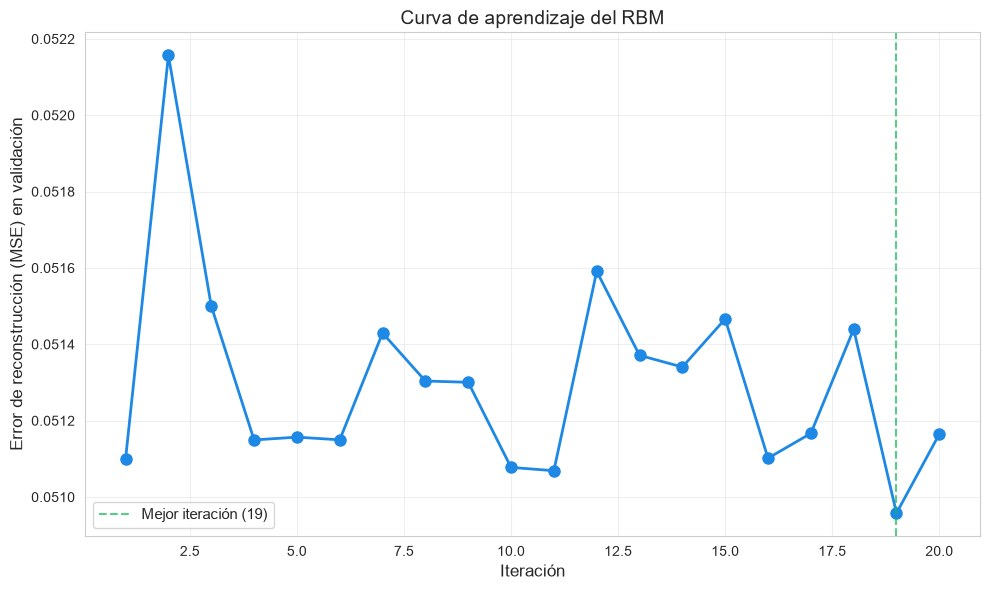


✅ Curva de aprendizaje guardada como 'rbm_learning_curve.png'
   Mejor iteración: 19 con MSE = 0.050958


In [ ]:
# 1. Extraer los mejores hiperparámetros del GridSearch
best_params = gs.best_params_

# 2. Crear un nuevo RBM con los mismos parámetros (sin entrenar)
rbm_for_curve = BernoulliRBM(
    n_components=best_params['n_components'],
    learning_rate=best_params['learning_rate'],
    batch_size=best_params['batch_size'],
    random_state=42,
    verbose=0  # Silencioso
)

# 3. Definir el número total de iteraciones (usar el mismo que en GridSearch, o un poco más)
n_iter_total = 20  # Coincide con el n_iter que pusiste en el GridSearch

# 4. Lista para almacenar el MSE de validación en cada iteración
val_errors_per_iter = []

# 5. Entrenar iterativamente
print("Entrenando RBM paso a paso para la curva de aprendizaje...")
for i in range(1, n_iter_total + 1):
    rbm_for_curve.n_iter = i
    rbm_for_curve.fit(X_train_rbm_scaled)
    
    # Calcular reconstrucción en validación
    hidden_val = rbm_for_curve.transform(X_val_rbm_scaled)
    def sigmoid(z):
        return 1 / (1 + np.exp(-z))
    recon_val = sigmoid(np.dot(hidden_val, rbm_for_curve.components_) + rbm_for_curve.intercept_visible_)
    mse_val = np.mean((X_val_rbm_scaled - recon_val) ** 2)
    val_errors_per_iter.append(mse_val)
    
    # Opcional: mostrar progreso
    print(f"Iteración {i}/{n_iter_total} - MSE validación: {mse_val:.6f}")

# 6. Graficar la curva de aprendizaje (usando la misma paleta)
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Curva de error de validación
plt.plot(range(1, n_iter_total + 1), val_errors_per_iter, 
         marker='o', linestyle='-', color=graph_palette[0], linewidth=2, markersize=8)

# Marcar la iteración con el menor error (mejor iteración)
best_iter = np.argmin(val_errors_per_iter) + 1  # +1 porque el índice empieza en 0
plt.axvline(x=best_iter, color=graph_palette[2], linestyle='--', alpha=0.7, 
            label=f'Mejor iteración ({best_iter})')

plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Error de reconstrucción (MSE) en validación', fontsize=12)
plt.title('Curva de aprendizaje del RBM', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('rbm_learning_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Curva de aprendizaje guardada como 'rbm_learning_curve.png'")
print(f"   Mejor iteración: {best_iter} con MSE = {val_errors_per_iter[best_iter-1]:.6f}")

In [ ]:
def reconstruction_error(rbm, X):
    # Paso 1: obtener activaciones ocultas
    h = rbm.transform(X)  # probabilidades
    # Paso 2: reconstruir las visibles a partir de las ocultas
    # Para BernoulliRBM, la media de la visible es: sigmoid(h @ W.T + intercept_visible)
    # Pero es más fácil usar el método gibbs() que da una muestra
    # O usar el atributo interno _mean_vis (pero no es público)
    # Alternativa: muestrear desde la visible condicionada a h
    # Usamos la función interna (pero no recomendada)
    # Podemos implementar manualmente:
    W = rbm.components_.T  # (n_features, n_components) según documentación
    b_v = rbm.intercept_visible_  # sesgo visible
    # Reconstrucción media (no muestreada)
    hidden_activation = h  # ya es probabilidad
    visible_mean = 1 / (1 + np.exp(-(hidden_activation @ W.T + b_v)))
    # Calcular error cuadrático medio
    return np.mean((X - visible_mean) ** 2)

# Calcular errores
error_train = reconstruction_error(rbm_for_curve, X_train_rbm_scaled)
error_test = reconstruction_error(rbm_for_curve, X_val_rbm_scaled)
print(f"Error de reconstrucción (MSE) en train: {error_train:.6f}")
print(f"Error de reconstrucción (MSE) en test: {error_test:.6f}")

Error de reconstrucción (MSE) en train: 0.051167
Error de reconstrucción (MSE) en test: 0.051165


### Error medio por variable

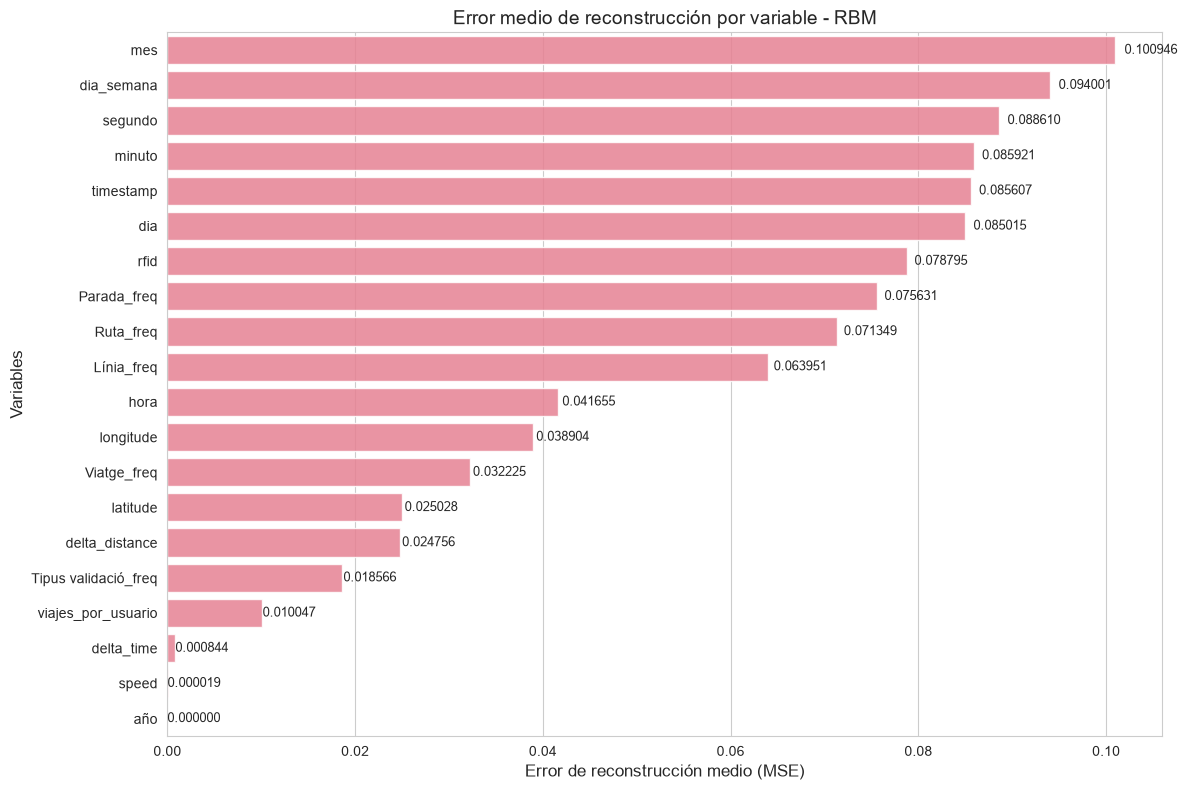

=== TOP 5 VARIABLES CON MAYOR ERROR (RBM) ===
  Variable      MSE
       mes 0.100946
dia_semana 0.094001
   segundo 0.088610
    minuto 0.085921
 timestamp 0.085607

=== TOP 5 VARIABLES CON MENOR ERROR (RBM) ===
            Variable          MSE
Tipus validació_freq 1.856615e-02
  viajes_por_usuario 1.004728e-02
          delta_time 8.436367e-04
               speed 1.908966e-05
                 año 1.339570e-08


In [ ]:
# 1. Obtener reconstrucciones en validación
hidden_val = best_rbm.transform(X_val_rbm_scaled)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
recon_val = sigmoid(np.dot(hidden_val, best_rbm.components_) + best_rbm.intercept_visible_)

# 2. Calcular error cuadrático medio (MSE) por variable (columna)
variable_errors_rbm = np.mean((X_val_rbm_scaled - recon_val) ** 2, axis=0)

# 3. Crear un DataFrame con los nombres de las variables
# Si tienes los nombres en X_train_rbm.columns, úsalos.
# Si no, crea nombres genéricos.
if hasattr(X_train_rbm, 'columns'):
    feature_names = X_train_rbm.columns
else:
    feature_names = [f'Variable_{i+1}' for i in range(len(variable_errors_rbm))]

df_var_errors_rbm = pd.DataFrame({
    'Variable': feature_names,
    'MSE': variable_errors_rbm
}).sort_values('MSE', ascending=False).reset_index(drop=True)

# 4. Graficar (barras horizontales)
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# Usar el primer color de la paleta para todas las barras
bars = sns.barplot(data=df_var_errors_rbm, y='Variable', x='MSE', 
                   color=graph_palette[0], alpha=0.85)

# Añadir etiquetas con el valor numérico al final de cada barra
for i, v in enumerate(df_var_errors_rbm['MSE']):
    bars.text(v + (v * 0.01), i, f'{v:.6f}', va='center', fontsize=9)

# Formato
plt.xlabel('Error de reconstrucción medio (MSE)', fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.title('Error medio de reconstrucción por variable - RBM', fontsize=14)
plt.tight_layout()
plt.savefig('rbm_variable_errors.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Mostrar las 5 variables con mayor y menor error
print("=== TOP 5 VARIABLES CON MAYOR ERROR (RBM) ===")
print(df_var_errors_rbm.head(5).to_string(index=False))
print("\n=== TOP 5 VARIABLES CON MENOR ERROR (RBM) ===")
print(df_var_errors_rbm.tail(5).to_string(index=False))

### Histograma y Boxplot

C:\Users\poshiro\AppData\Local\Temp\ipykernel_4424\2402622304.py:13: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.histplot(data=df_hist_rbm, x='Error', hue='Tipo',


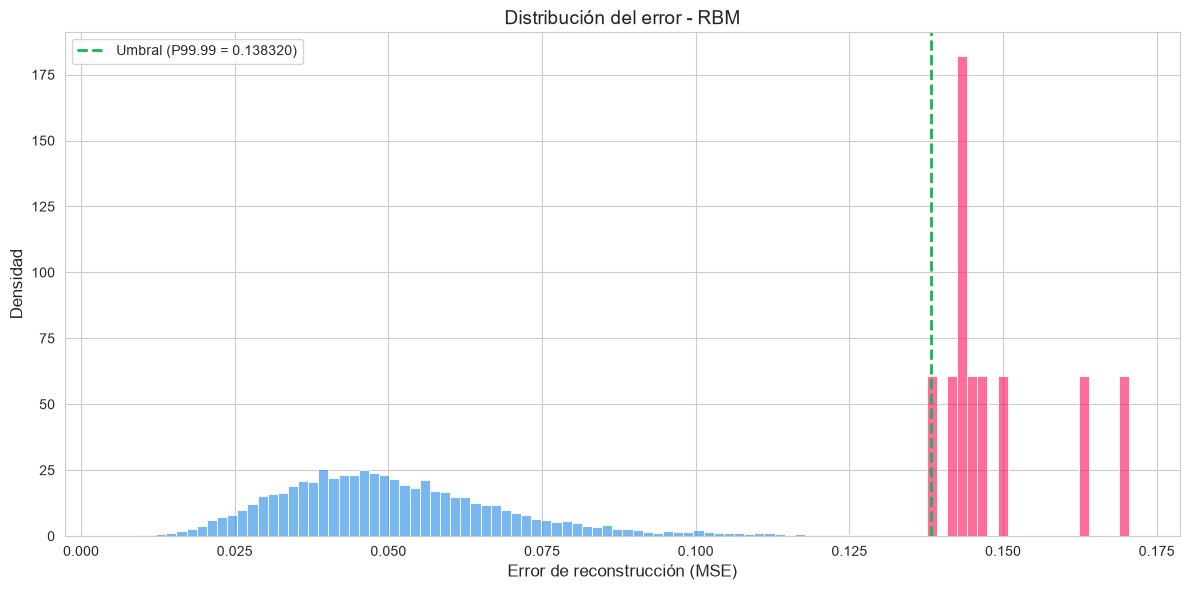

C:\Users\poshiro\AppData\Local\Temp\ipykernel_4424\2402622304.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hist_rbm, x='Tipo', y='Error', palette=graph_palette)
C:\Users\poshiro\AppData\Local\Temp\ipykernel_4424\2402622304.py:28: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(data=df_hist_rbm, x='Tipo', y='Error', palette=graph_palette)


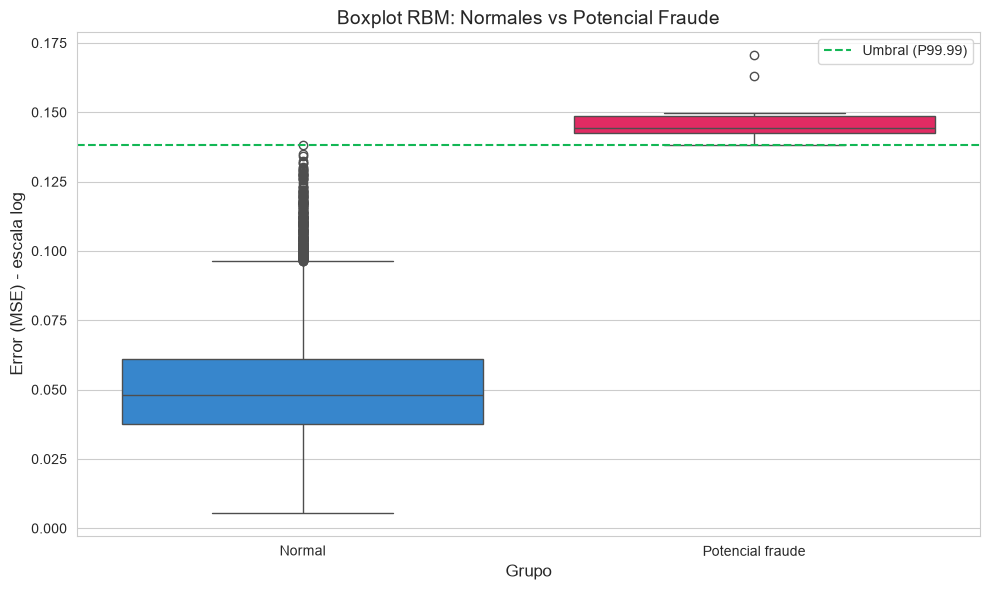

In [ ]:
# ------------------------------------------------------------
# 5. GRÁFICOS (HISTOGRAMA Y BOXPLOT)
# ------------------------------------------------------------
# Usamos la paleta definida anteriormente (graph_palette)

# Histograma
df_hist_rbm = pd.DataFrame({
    'Error': val_errors_rbm,
    'Tipo': np.where(anomalies_rbm, 'Potencial fraude', 'Normal')
})

plt.figure(figsize=(12, 6))
sns.histplot(data=df_hist_rbm, x='Error', hue='Tipo',
             bins=100, palette=graph_palette, alpha=0.6,
             stat='density', common_norm=False)
plt.axvline(x=threshold_rbm, color=graph_palette[2], linestyle='--', linewidth=2,
            label=f'Umbral (P99.99 = {threshold_rbm:.6f})')
plt.xlabel('Error de reconstrucción (MSE)', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.title('Distribución del error - RBM', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('rbm_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

# Boxplot (escala log)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_hist_rbm, x='Tipo', y='Error', palette=graph_palette)
# plt.yscale('log')
plt.axhline(y=threshold_rbm, color=graph_palette[2], linestyle='--', linewidth=1.5,
            label='Umbral (P99.99)')
plt.xlabel('Grupo', fontsize=12)
plt.ylabel('Error (MSE) - escala log', fontsize=12)
plt.title('Boxplot RBM: Normales vs Potencial Fraude', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('rbm_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


### Comprovación de fraude

In [ ]:
# Extraer los casos y escalarlos con el mismo scaler
fraud_cases = df_val_par.loc[fraud_idx].drop('coord_imputada', axis=1)  # eliminar columna no usada
fraud_cases_scaled = rbm_scaler.transform(fraud_cases)

# Reconstrucción
hidden_fraud = best_rbm.transform(fraud_cases_scaled)
recon_fraud = sigmoid(np.dot(hidden_fraud, best_rbm.components_) + best_rbm.intercept_visible_)
fraud_errors_rbm = np.mean((fraud_cases_scaled - recon_fraud) ** 2, axis=1)

# Clasificación
detected_rbm = fraud_errors_rbm > threshold_rbm

results_rbm_fraud = pd.DataFrame({
    'ID': fraud_idx,
    'Error': fraud_errors_rbm,
    'Detectado': detected_rbm
})
print("\n=== DETECCIÓN DE FRAUDES (RBM) ===")
print(results_rbm_fraud)
print(f"Detectados: {np.sum(detected_rbm)} de {len(fraud_idx)}")


=== DETECCIÓN DE FRAUDES (RBM) ===
        ID     Error  Detectado
0   608261  0.096614      False
1  4707488  0.995824       True
2  1264656  2.230624       True
3  3294844  0.517379       True
4   325168  3.620981       True
5   811310  0.363854       True
6  5195084  0.504958       True
Detectados: 6 de 7


## Self-organized maps

### Datos

In [ ]:
som_data = df_val_par.drop('coord_imputada', axis=1)

# Muestreo para GridSearch (rápido)
muestra_size = 50000
np.random.seed(42)
indices_muestra = np.random.choice(len(som_data), muestra_size, replace=False)
som_data_subset = som_data.iloc[indices_muestra]  # DataFrame con las filas muestreadas

# Escalado
som_scaler = MinMaxScaler()
X_som_scaled_subset = som_scaler.fit_transform(som_data_subset)

### Entrenamiento

In [ ]:
# Separation Scorer
def separation_scorer(estimator, X, y=None):
    """Calcula la separación entre inliers y outliers para un SOM ya ajustado."""
    errors = estimator.transform(X).flatten()
    n_outliers = int(muestra_size*0.0001)
    outlier_idx = np.argsort(errors)[-n_outliers:]
    labels = np.ones(len(errors), dtype=int)
    labels[outlier_idx] = -1
    # Separación = media(inliers) - media(outliers) -> Cuanto mayor, mejor
    sep = np.mean(errors[labels == 1]) - np.mean(errors[labels == -1])
    return sep

In [ ]:
# Clase wrapper
class MiniSomWrapper(BaseEstimator, TransformerMixin):
    """
    Wrapper para MiniSom que permite usarlo en GridSearchCV.
    - fit(): Entrena el SOM con los datos.
    - transform(): Devuelve el error de cuantización (distancia a la BMU) por muestra.
    """
    def __init__(self, x=10, y=10, sigma=1.0, learning_rate=0.5, random_seed=42):
        self.x = x
        self.y = y
        self.sigma = sigma
        self.learning_rate = learning_rate
        self.random_seed = random_seed
        self.som = None

    def fit(self, X, y=None):
        # Inicializar SOM
        self.som = MiniSom(
            x=self.x,
            y=self.y,
            input_len=X.shape[1],
            sigma=self.sigma,
            learning_rate=self.learning_rate,
            neighborhood_function='gaussian',
            random_seed=self.random_seed
        )
        # Inicializar pesos
        self.som.random_weights_init(X)
        # Entrenar con 200 iteraciones (suficiente para comparar en GridSearch)
        self.som.train_batch(X, 200, verbose=False)
        return self

    def transform(self, X):
        if self.som is None:
            raise RuntimeError("El SOM no ha sido entrenado. Llama a fit() primero.")
        
        errors = []
        for v in X:
            bmu = self.som.winner(v)
            w = self.som.get_weights()[bmu[0], bmu[1]]
            errors.append(np.linalg.norm(v - w))
        return np.array(errors).reshape(-1, 1)

    def get_params(self, deep=True):
        return {
            'x': self.x,
            'y': self.y,
            'sigma': self.sigma,
            'learning_rate': self.learning_rate,
            'random_seed': self.random_seed
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

In [ ]:
# Configuración de la red
param_grid = {
    'x': [10, 15, 20],          # Tamaño del grid en X
    'y': [10, 15, 20],          # Tamaño del grid en Y
    'sigma': [0.5, 1.0, 1.5],  # Radio del vecindario
    'learning_rate': [0.1, 0.5, 1.0]  # Tasa de aprendizaje
}

In [ ]:
# Entrenamiento
train_idx, test_idx = train_test_split(
    np.arange(len(X_som_scaled_subset)),
    test_size=0.2,
    random_state=42
)
test_fold = np.zeros(len(X_som_scaled_subset))
test_fold[train_idx] = -1  # -1 = entrenamiento, 0 = test

print("🔄 Iniciando GridSearch para SOM (81 combinaciones)...")

gs = GridSearchCV(
    MiniSomWrapper(random_seed=42),
    param_grid,
    cv=PredefinedSplit(test_fold),
    scoring=separation_scorer,
    n_jobs=1,  # MiniSom no es paralelizable
    refit=True,
    verbose=2   # Muestra el progreso
)

gs.fit(X_som_scaled_subset)

print(f" GridSearch completado")

🔄 Iniciando GridSearch para SOM (81 combinaciones)...
Fitting 1 folds for each of 81 candidates, totalling 81 fits
[CV] END ...........learning_rate=0.1, sigma=0.5, x=10, y=10; total time=   0.3s
[CV] END ...........learning_rate=0.1, sigma=0.5, x=10, y=15; total time=   0.4s
[CV] END ...........learning_rate=0.1, sigma=0.5, x=10, y=20; total time=   0.4s
[CV] END ...........learning_rate=0.1, sigma=0.5, x=15, y=10; total time=   0.2s
[CV] END ...........learning_rate=0.1, sigma=0.5, x=15, y=15; total time=   0.4s
[CV] END ...........learning_rate=0.1, sigma=0.5, x=15, y=20; total time=   0.5s
[CV] END ...........learning_rate=0.1, sigma=0.5, x=20, y=10; total time=   0.4s
[CV] END ...........learning_rate=0.1, sigma=0.5, x=20, y=15; total time=   0.4s
[CV] END ...........learning_rate=0.1, sigma=0.5, x=20, y=20; total time=   0.5s
[CV] END ...........learning_rate=0.1, sigma=1.0, x=10, y=10; total time=   0.3s
[CV] END ...........learning_rate=0.1, sigma=1.0, x=10, y=15; total time=  

In [ ]:
# reentrenamos con la mejor configuracion
best_som_wrapper = gs.best_estimator_
best_som = best_som_wrapper.som
best_params = gs.best_params_

print("✅ Mejor modelo extraído del GridSearch")
print(f"   Mejores parámetros: {best_params}")

✅ Mejor modelo extraído del GridSearch
   Mejores parámetros: {'learning_rate': 1.0, 'sigma': 0.5, 'x': 20, 'y': 10}


In [ ]:
# ------------------------------------------------------------
# 2. CALCULAR DISTANCIAS A LA BMU PARA TODAS LAS MUESTRAS
# ------------------------------------------------------------
# Usamos los mismos datos que se usaron en el GridSearch (refit=True entrenó con todos)
# Obtener los pesos del SOM
weights = best_som.get_weights()  # (x, y, input_len)

# Calcular BMU y distancias
bmu_indices = []
distances = []

for x in X_som_scaled_subset:
    # Calcular distancia euclidiana a todas las neuronas
    dist_to_neurons = np.linalg.norm(weights - x, axis=2)  # (x, y)
    # Encontrar la BMU (índice de la neurona con menor distancia)
    bmu_idx = np.unravel_index(np.argmin(dist_to_neurons), dist_to_neurons.shape)
    bmu_indices.append(bmu_idx)
    # Distancia mínima (a la BMU)
    distances.append(dist_to_neurons[bmu_idx])

# Convertir a arrays
bmu_indices = np.array(bmu_indices)
distances = np.array(distances)

print(f"🔍 Distancias calculadas para {len(distances)} muestras.")

# ------------------------------------------------------------
# 3. SELECCIONAR OUTLIERS (0.01% DE LA MUESTRA)
# ------------------------------------------------------------
PROPORCION_OUTLIERS = 0.0001  # 0.01%
n_outliers = int(len(X_som_scaled_subset) * PROPORCION_OUTLIERS)
if n_outliers < 1:
    n_outliers = 1

# Índices de los outliers (posiciones en X_data)
outlier_positions = np.argsort(distances)[-n_outliers:]

# Índices originales (si X_som_scaled_subset era un DataFrame, recupera sus índices)
if hasattr(X_som_scaled_subset, 'index'):
    outlier_indices_som = X_som_scaled_subset.index[outlier_positions].tolist()
else:
    # Si es un array, no tenemos índice original; usamos posiciones
    outlier_indices_som = outlier_positions.tolist()

print(f"🔍 Outliers seleccionados: {len(outlier_indices_som)} de {len(X_som_scaled_subset)}")

# ------------------------------------------------------------
# 4. CALCULAR MÉTRICAS (usando las distancias)
# ------------------------------------------------------------
labels_som = np.ones(len(distances), dtype=int)
labels_som[outlier_positions] = -1

outlier_scores = distances[labels_som == -1]
inlier_scores = distances[labels_som == 1]

metrics_som = {
    'kurtosis': pd.Series(distances).kurtosis(),
    'gap': (np.mean(distances) - np.median(distances)) / (np.std(distances) + 1e-9),
    'outlier_mean': np.mean(outlier_scores) if len(outlier_scores) > 0 else np.nan,
    'inlier_mean': np.mean(inlier_scores) if len(inlier_scores) > 0 else np.nan,
    'separation': np.mean(inlier_scores) - np.mean(outlier_scores) if len(outlier_scores) > 0 else np.nan,
}

print("\n📈 Métricas del SOM final:")
for k, v in metrics_som.items():
    print(f"   {k}: {v:.6f}")

🔍 Distancias calculadas para 50000 muestras.
🔍 Outliers seleccionados: 5 de 50000

📈 Métricas del SOM final:
   kurtosis: 2.606386
   gap: 0.085584
   outlier_mean: 1.460072
   inlier_mean: 0.667544
   separation: -0.792528


### Visualizaciones

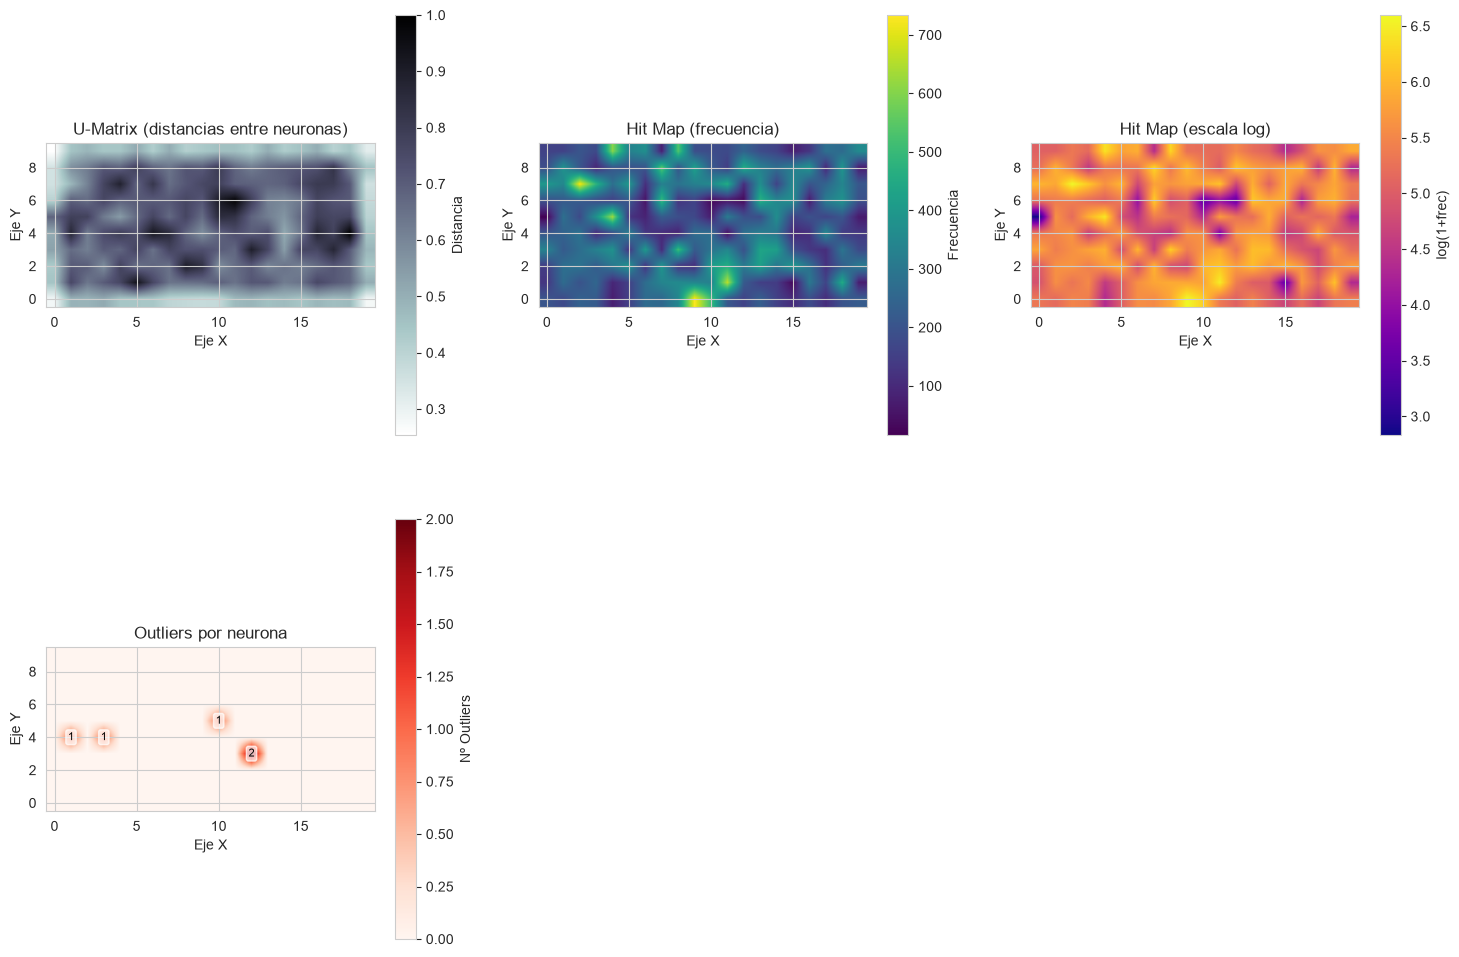

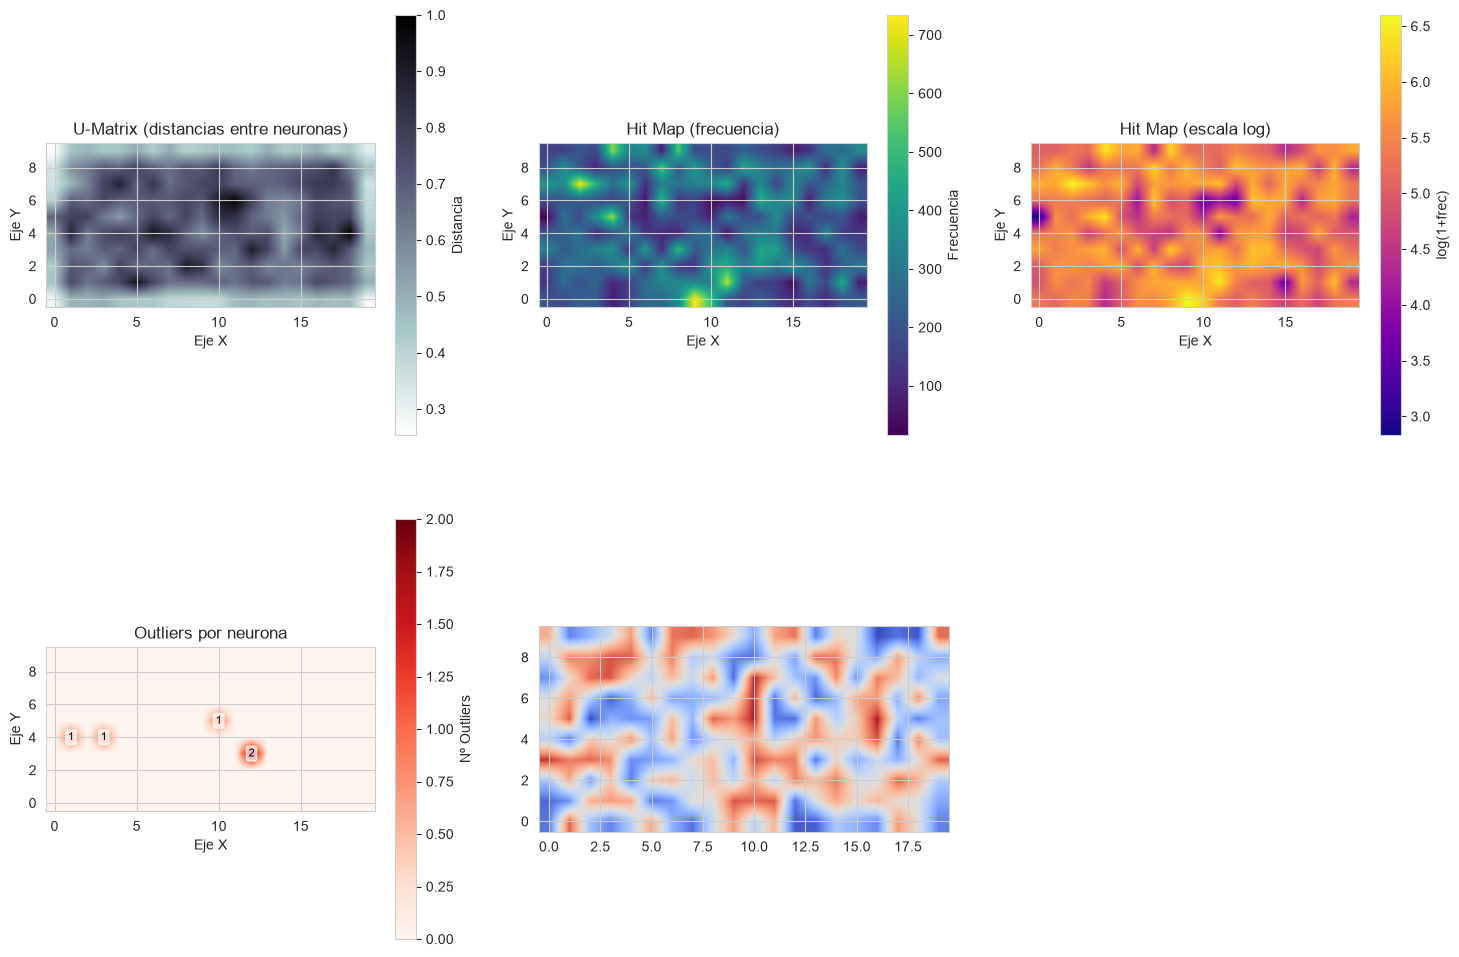

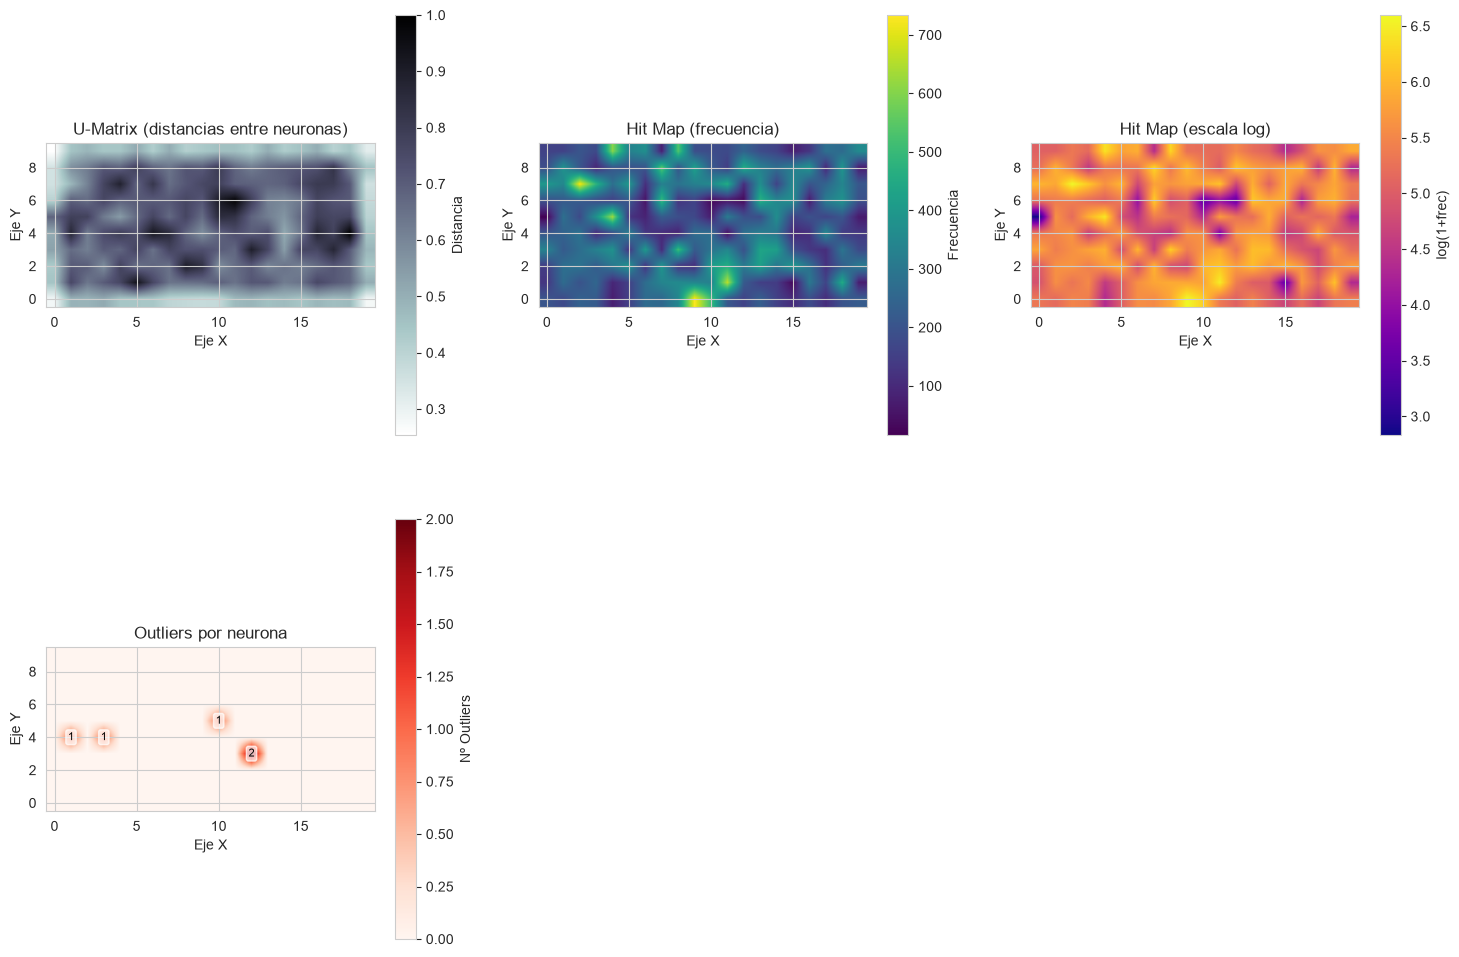

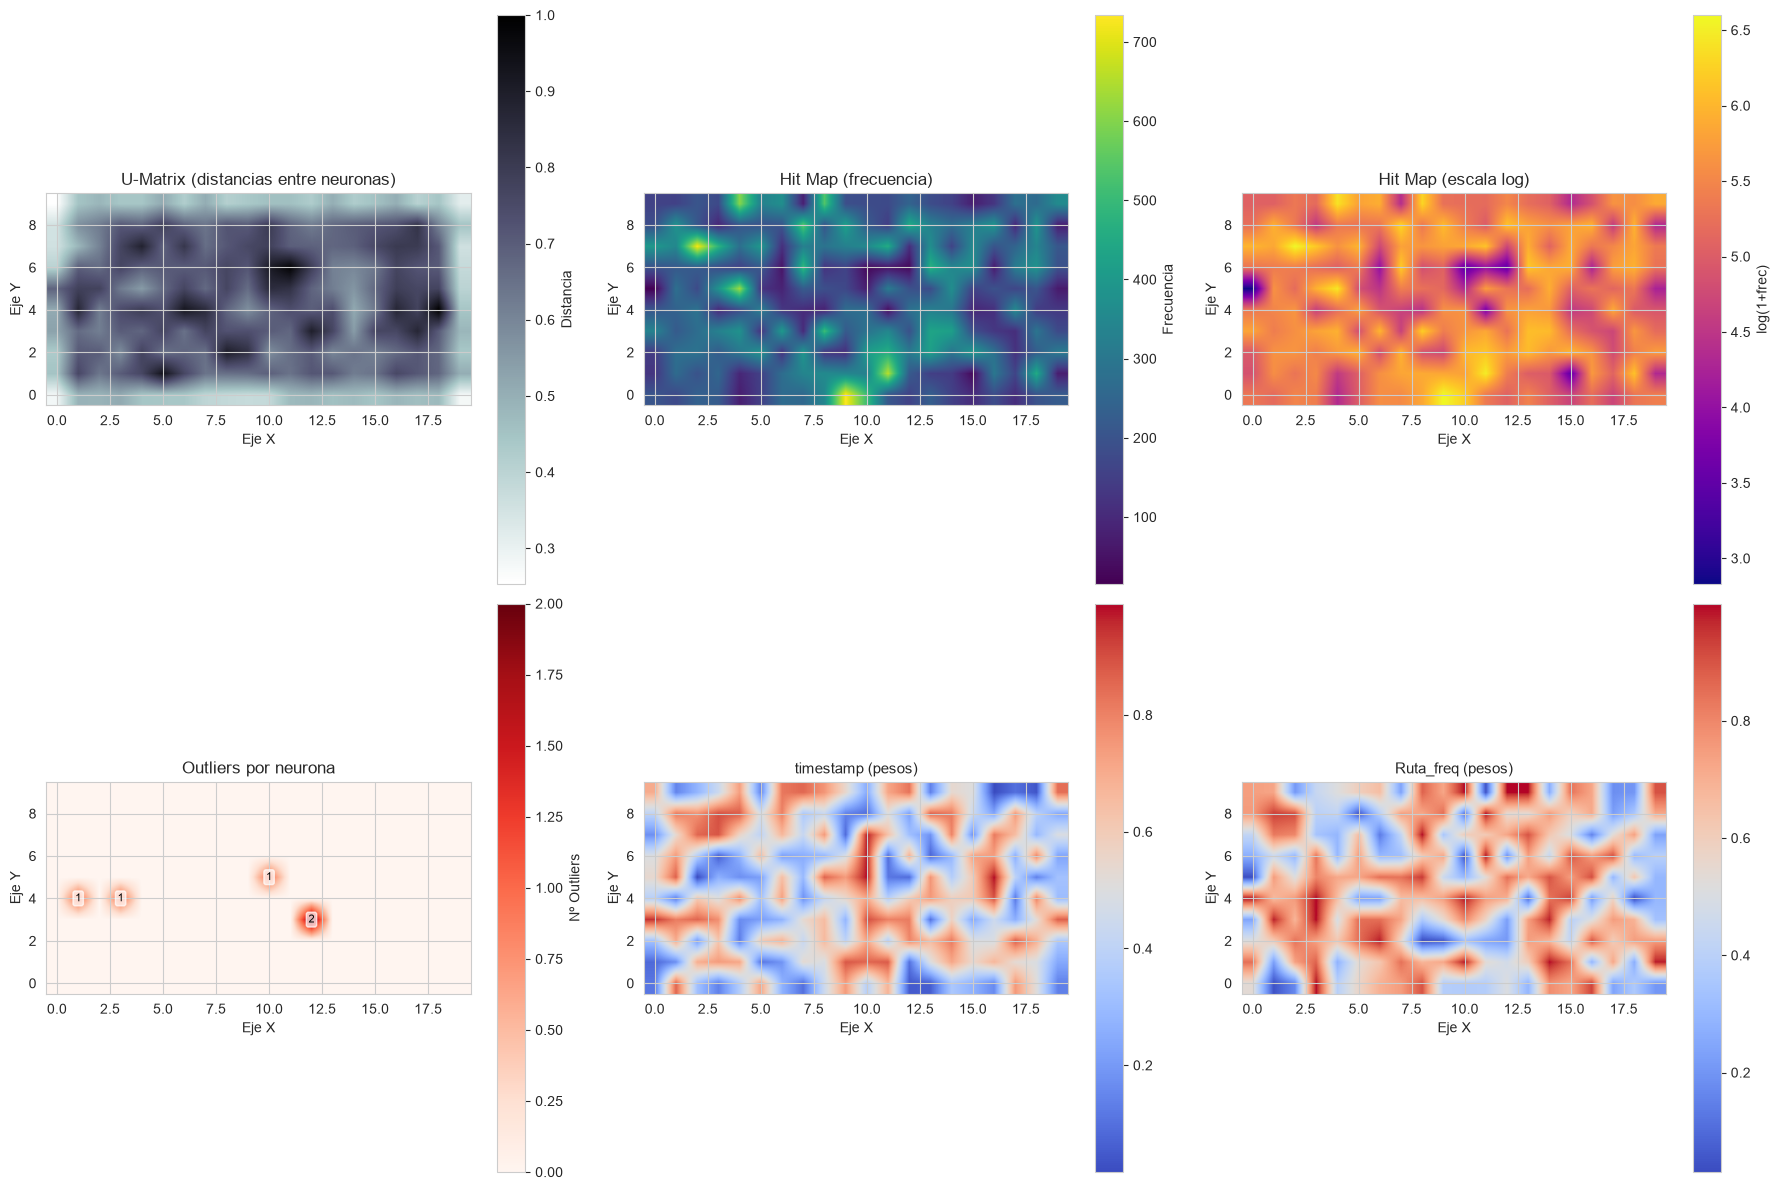

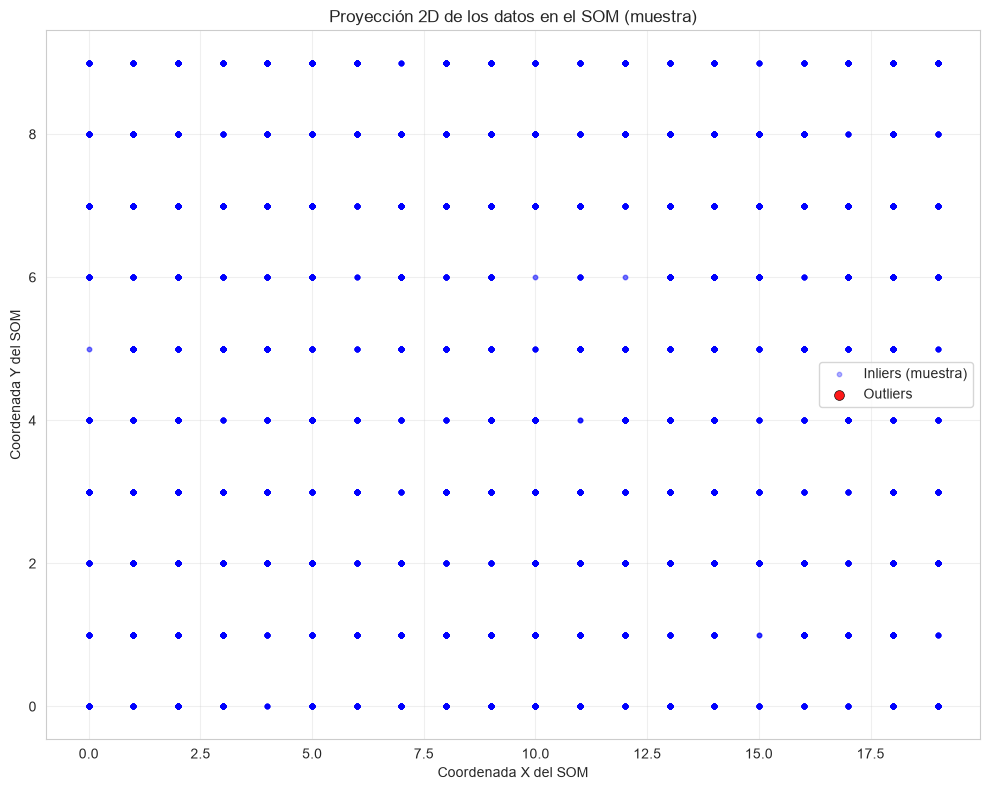

In [ ]:
# --------------------------------------------------
# 5. VISUALIZACIONES (versión corregida)
# --------------------------------------------------

# --- Asegurar que outlier_indices_som sean índices de posición en la muestra ---
# Si outlier_indices_som son índices originales, conviértelos:
# outlier_pos = [np.where(original_indices == idx)[0][0] for idx in outlier_indices_som] 
# (depende de cómo hayas construido la muestra)
# Por ahora, asumo que ya son posiciones en X_som_scaled_subset:
outlier_pos = outlier_indices_som  # si no, haz la conversión aquí

# --- Crear figura principal con GridSpec ---
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3)  # forma más moderna

# 5a. U-Matrix
ax1 = fig.add_subplot(gs[0, 0])
u_matrix = best_som.distance_map().T
im1 = ax1.imshow(u_matrix, cmap='bone_r', interpolation='bilinear', origin='lower')
ax1.set_title('U-Matrix (distancias entre neuronas)')
ax1.set_xlabel('Eje X'); ax1.set_ylabel('Eje Y')
plt.colorbar(im1, ax=ax1, label='Distancia')

# 5b. Hit Map (frecuencia)
ax2 = fig.add_subplot(gs[0, 1])
winners = np.array([best_som.winner(x) for x in X_som_scaled_subset])
hit_map = np.zeros((best_params['x'], best_params['y']))
for x, y in winners:
    hit_map[x, y] += 1
im2 = ax2.imshow(hit_map.T, cmap='viridis', interpolation='bilinear', origin='lower')
ax2.set_title('Hit Map (frecuencia)')
ax2.set_xlabel('Eje X'); ax2.set_ylabel('Eje Y')
plt.colorbar(im2, ax=ax2, label='Frecuencia')

# 5c. Hit Map logarítmico
ax3 = fig.add_subplot(gs[0, 2])
hit_log = np.log1p(hit_map)
im3 = ax3.imshow(hit_log.T, cmap='plasma', interpolation='bilinear', origin='lower')
ax3.set_title('Hit Map (escala log)')
ax3.set_xlabel('Eje X'); ax3.set_ylabel('Eje Y')
plt.colorbar(im3, ax=ax3, label='log(1+frec)')

# 5d. Outliers en el mapa (con corrección de índices)
ax4 = fig.add_subplot(gs[1, 0])
optimal_x, optimal_y = best_params['x'], best_params['y']
outlier_hit = np.zeros((optimal_x, optimal_y))
for pos in outlier_pos:   # ahora pos es índice en la muestra
    x, y = best_som.winner(X_som_scaled_subset[pos])
    outlier_hit[x, y] += 1

im4 = ax4.imshow(outlier_hit.T, cmap='Reds', interpolation='bilinear', origin='lower')
ax4.set_title('Outliers por neurona')
ax4.set_xlabel('Eje X'); ax4.set_ylabel('Eje Y')
plt.colorbar(im4, ax=ax4, label='Nº Outliers')
# Etiquetas con número
for i in range(optimal_x):
    for j in range(optimal_y):
        if outlier_hit[i, j] > 0:
            ax4.text(i, j, int(outlier_hit[i, j]),
                     color='black', fontsize=8, ha='center', va='center',
                     bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# 5e. Planos de componentes (ocupando columnas 1 y 2 de la fila inferior)
weights = best_som.get_weights()  # shape (x, y, n_features)
n_features = weights.shape[2]
feature_names = som_data.columns
# Seleccionamos las 6 más variables, pero solo mostraremos las 2 primeras en el grid
# Si quieres más, cambia el GridSpec o crea otra figura.
var_per_feature = np.var(weights, axis=(0, 1))
top_features_idx = np.argsort(var_per_feature)[-6:]  # top 6
for k, idx in enumerate(top_features_idx[:2]):  # solo 2
    ax = fig.add_subplot(gs[1, 1 + k])  # col 1,2
    component_map = weights[:, :, idx]
    im = ax.imshow(component_map.T, cmap='coolwarm', interpolation='bilinear', origin='lower')
    # Nombre de la característica
        # Usar el nombre real de la característica
    feat_name = feature_names[idx]
    ax.set_title(f'{feat_name} (pesos)', fontsize=11)
    ax.set_xlabel('Eje X'); ax.set_ylabel('Eje Y')
    plt.colorbar(im, ax=ax)

# Si quieres mostrar más de 2, puedes añadir una figura extra o usar un grid diferente.
# Por ahora, solo mostramos 2.

# 5f. Proyección 2D (muestra) - Crear figura separada
sample_size = 10000
if len(X_som_scaled_subset) > sample_size:
    np.random.seed(42)
    sample_idx = np.random.choice(len(X_som_scaled_subset), sample_size, replace=False)
else:
    sample_idx = np.arange(len(X_som_scaled_subset))

sample_coords = np.array([best_som.winner(X_som_scaled_subset[i]) for i in sample_idx])
# Asegurar que labels_som exista y tenga misma longitud que X_som_scaled_subset
sample_labels = labels_som[sample_idx]  # asumo que labels_som es array de -1/1

fig2, ax_extra = plt.subplots(figsize=(10, 8))
inlier_mask = sample_labels == 1
outlier_mask = sample_labels == -1
ax_extra.scatter(sample_coords[inlier_mask, 0], sample_coords[inlier_mask, 1],
                 c='blue', alpha=0.3, s=10, label='Inliers (muestra)')
ax_extra.scatter(sample_coords[outlier_mask, 0], sample_coords[outlier_mask, 1],
                 c='red', alpha=0.9, s=50, label='Outliers', edgecolors='black', linewidth=0.5)
ax_extra.set_xlabel('Coordenada X del SOM')
ax_extra.set_ylabel('Coordenada Y del SOM')
ax_extra.set_title('Proyección 2D de los datos en el SOM (muestra)')
ax_extra.legend()
ax_extra.grid(True, alpha=0.3)
fig2.tight_layout()

# Ajustar y mostrar ambas figuras
fig.tight_layout()
plt.show()   # muestra ambas figuras (la última activa es fig2, pero fig ya está dibujada)

In [ ]:
# ----------------------------------------------
# 1. Error de Cuantización (Quantization Error)
# ----------------------------------------------
# Si tu SOM tiene el método quantization_error (minisom):
qe = best_som.quantization_error(X_som_scaled_subset)
print(f"Quantization Error (medio): {qe:.4f}")

# Si no, lo calculamos manualmente:
def quantization_error_manual(som, data):
    errors = []
    for x in data:
        winner_coords = som.winner(x)
        winner_weights = som.get_weights()[winner_coords[0], winner_coords[1], :]
        dist = np.linalg.norm(x - winner_weights)
        errors.append(dist)
    return np.mean(errors), errors  # devolvemos media y lista de errores

qe_mean, qe_errors = quantization_error_manual(best_som, X_som_scaled_subset)
print(f"Quantization Error (medio) manual: {qe_mean:.4f}")

# ----------------------------------------------
# 2. Error Topográfico (Topographic Error)
# ----------------------------------------------
# Si tu SOM tiene el método topographic_error (minisom):
te = best_som.topographic_error(X_som_scaled_subset)
print(f"Topographic Error: {te:.4f} (proporción)")

# Si no, lo calculamos manualmente:
def topographic_error_manual(som, data):
    weights = som.get_weights()
    n_neurons = weights.shape[0] * weights.shape[1]
    # Precalculamos distancias a todas las neuronas para cada punto
    errors = 0
    n_samples = len(data)
    for x in data:
        # Calcular distancias a todas las neuronas
        dists = np.zeros((weights.shape[0], weights.shape[1]))
        for i in range(weights.shape[0]):
            for j in range(weights.shape[1]):
                dists[i, j] = np.linalg.norm(x - weights[i, j, :])
        # Encontrar las dos neuronas con menor distancia
        flat_dists = dists.flatten()
        sorted_idx = np.argsort(flat_dists)
        best_idx = np.unravel_index(sorted_idx[0], dists.shape)  # (i1, j1)
        second_idx = np.unravel_index(sorted_idx[1], dists.shape)  # (i2, j2)
        # Verificar si son vecinas (distancia Manhattan = 1)
        if abs(best_idx[0] - second_idx[0]) + abs(best_idx[1] - second_idx[1]) > 1:
            errors += 1
    return errors / n_samples

te_manual = topographic_error_manual(best_som, X_som_scaled_subset)
print(f"Topographic Error (manual): {te_manual:.4f} (proporción)")

# También puedes calcular el error topográfico basado en la segunda mejor BMU (más común):
# Algunas implementaciones usan la segunda mejor BMU (no necesariamente la segunda neurona más cercana en distancia)
# La versión anterior usa las dos neuronas con menor distancia, que es la definición estándar.

Quantization Error (medio): 0.6676
Quantization Error (medio) manual: 0.6676
Topographic Error: 0.9571 (proporción)
Topographic Error (manual): 0.9747 (proporción)


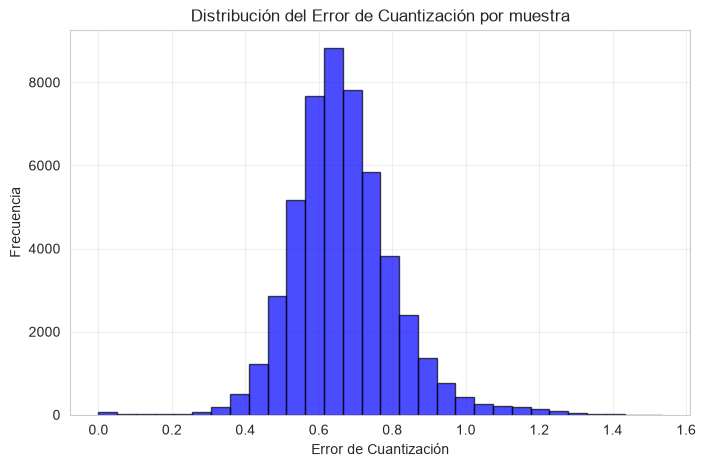

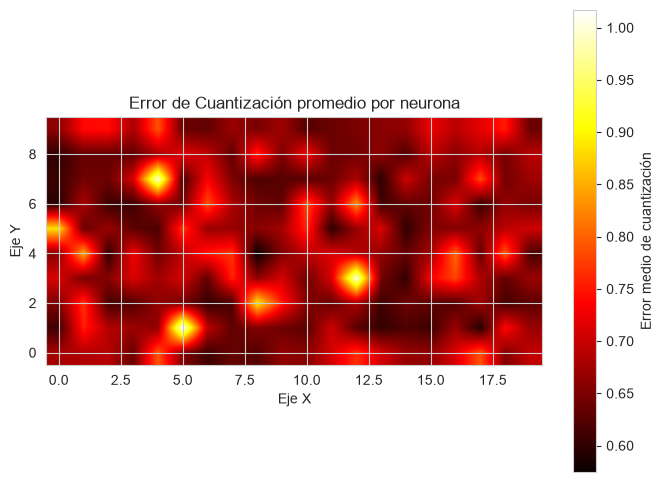

In [ ]:
# Calcular errores individuales (si no los tenemos ya)
_, errors_list = quantization_error_manual(best_som, X_som_scaled_subset)

# Histograma
plt.figure(figsize=(8, 5))
plt.hist(errors_list, bins=30, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('Error de Cuantización')
plt.ylabel('Frecuencia')
plt.title('Distribución del Error de Cuantización por muestra')
plt.grid(True, alpha=0.3)
plt.show()

# También podemos proyectar estos errores en el mapa SOM (similar a hit map pero con error promedio por neurona)
error_map = np.zeros((best_som.get_weights().shape[0], best_som.get_weights().shape[1]))
count_map = np.zeros_like(error_map)

for idx, x in enumerate(X_som_scaled_subset):
    win = best_som.winner(x)
    error_map[win[0], win[1]] += errors_list[idx]
    count_map[win[0], win[1]] += 1

# Evitar división por cero
count_map[count_map == 0] = 1
error_map_mean = error_map / count_map

plt.figure(figsize=(8, 6))
plt.imshow(error_map_mean.T, cmap='hot', interpolation='bilinear', origin='lower')
plt.colorbar(label='Error medio de cuantización')
plt.title('Error de Cuantización promedio por neurona')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.show()

### Comprovación de fraude

In [ ]:
# 1. Extraer los datos de los fraudes del DataFrame original
fraud_data = df_val_par.drop('coord_imputada', axis=1).loc[fraud_idx]  # DataFrame con las mismas columnas
# 2. Escalar los fraudes con el mismo scaler
fraud_scaled = som_scaler.transform(fraud_data)  # array numpy

# 3. Calcular para cada punto de entrenamiento su distancia a su BMU (para definir umbral)
#    Esto ya lo habrás hecho para obtener outlier_indices_som, pero si no, lo calculamos ahora.
train_distances = []
for x in X_train_scaled:
    bmu = best_som.winner(x)
    # vector de pesos de la BMU
    weight_vector = best_som.get_weights()[bmu[0], bmu[1], :]
    dist = np.linalg.norm(x - weight_vector)
    train_distances.append(dist)
train_distances = np.array(train_distances)

# 4. Definir el umbral (percentil, por ejemplo 95)
percentile = 99.99  # o el que usaste
threshold = np.percentile(train_distances, percentile)
print(f"Umbral de distancia (percentil {percentile}): {threshold:.4f}")

# 5. Para cada fraude, calcular su distancia a su BMU
fraud_bmus = []
fraud_distances = []
for x in fraud_scaled:
    bmu = best_som.winner(x)
    weight_vector = best_som.get_weights()[bmu[0], bmu[1], :]
    dist = np.linalg.norm(x - weight_vector)
    fraud_bmus.append(bmu)
    fraud_distances.append(dist)

# 6. Clasificar según el umbral: si distancia > threshold -> outlier (fraude detectado)
fraud_predicted = np.array(fraud_distances) > threshold

# 7. Crear DataFrame de resultados
resultados = pd.DataFrame({
    'indice_original': fraud_idx,
    'fraude_real': True,   # todos son fraudes reales
    'distancia_BMU': fraud_distances,
    'prediccion_outlier': fraud_predicted,
    'detectado_como_fraude': fraud_predicted  # si tu modelo considera outlier = fraude
})

# Añadir coordenadas BMU si quieres
resultados['BMU_x'] = [b[0] for b in fraud_bmus]
resultados['BMU_y'] = [b[1] for b in fraud_bmus]

# 8. Resumen
total_fraudes = len(resultados)
detectados = resultados['prediccion_outlier'].sum()
print(f"\nTotal fraudes reales: {total_fraudes}")
print(f"Detectados por el modelo SOM: {detectados} ({detectados/total_fraudes:.2%})")

# Mostrar primeros resultados
print(resultados)

Umbral de distancia (percentil 99.99): 1.4139

Total fraudes reales: 7
Detectados por el modelo SOM: 6 (85.71%)
   indice_original  fraude_real  distancia_BMU  prediccion_outlier  \
0           608261         True       1.176133               False   
1          4707488         True       4.459679                True   
2          1264656         True       6.780369                True   
3          3294844         True       3.147799                True   
4           325168         True       8.581197                True   
5           811310         True       2.628579                True   
6          5195084         True       3.078149                True   

   detectado_como_fraude  BMU_x  BMU_y  
0                  False      2      2  
1                   True      6      9  
2                   True      1      4  
3                   True     11      3  
4                   True     19      1  
5                   True      6      0  
6                   True      1      5  

## Adaptive Reconstruction Threshold

In [ ]:
def get_reconstruction_errors(rbm, X):
    result = rbm.gibbs(X)
    # Si es una tupla, toma el primer elemento; si es un array, úsalo directamente
    if isinstance(result, tuple):
        v_sample = result[0]
    else:
        v_sample = result
    return np.mean((X - v_sample) ** 2, axis=1)

# Errores para todos los datos (normales + fraudulentos)
reconstruction_errors_all = get_reconstruction_errors(rbm_for_curve, X_som_scaled_subset)

# Errores solo para los datos de entrenamiento (normales)
reconstruction_errors_train = get_reconstruction_errors(rbm_for_curve, X_train_rbm_scaled)

In [ ]:
def get_bmu_indices(som, X):
    """Devuelve los índices (x, y) de la BMU para cada muestra."""
    bmus = np.array([som.winner(x) for x in X])
    return bmus

# BMU para todos los datos
bmu_all = get_bmu_indices(best_som, X_som_scaled_subset)  # Asumiendo que best_som.som es el objeto MiniSom

# BMU solo para los datos de entrenamiento (normales)
bmu_train = get_bmu_indices(best_som, X_train_rbm_scaled)

In [ ]:
def compute_adaptive_thresholds(som, X_train, errors_train, bmu_train, percentile=95):
    """
    Calcula un umbral adaptativo para cada neurona del SOM.
    
    Args:
        som: Modelo MiniSom entrenado.
        X_train: Datos de entrenamiento (normales).
        errors_train: Errores de reconstrucción para X_train.
        bmu_train: Índices de las BMU para X_train.
        percentile: Percentil para definir el umbral (ej. 95).
    
    Returns:
        Diccionario con umbrales por neurona (clave: (x, y), valor: umbral).
    """
    grid_x, grid_y = som.get_weights().shape[:2]
    thresholds = {}
    
    # Inicializar diccionario para almacenar errores por neurona
    errors_by_neuron = {(i, j): [] for i in range(grid_x) for j in range(grid_y)}
    
    # Agrupar errores por neurona
    for i, (x, y) in enumerate(bmu_train):
        errors_by_neuron[(x, y)].append(errors_train[i])
    
    # Calcular umbral para cada neurona
    for (x, y), errors in errors_by_neuron.items():
        if len(errors) > 0:
            # Calcular el percentil de los errores en esta neurona
            thresholds[(x, y)] = np.percentile(errors, percentile)
        else:
            # Si no hay muestras normales en esta neurona, usar un umbral global
            # (por ejemplo, el percentil de todos los errores de entrenamiento)
            thresholds[(x, y)] = np.percentile(errors_train, percentile)
    
    return thresholds

# Calcular umbrales adaptativos
adaptive_thresholds = compute_adaptive_thresholds(
    best_som, 
    X_train_rbm_scaled, 
    reconstruction_errors_train, 
    bmu_train,
    percentile=99.99  # Ajusta este valor según tu necesidad
)

In [ ]:
def predict_anomalies_adaptive(rbm, som, X_new, thresholds):
    """
    Clasifica nuevas transacciones usando umbrales adaptativos.
    
    Args:
        rbm: Modelo RBM entrenado.
        som: Modelo SOM entrenado.
        X_new: Nuevos datos a clasificar.
        thresholds: Diccionario de umbrales por neurona.
    
    Returns:
        Array con 1 para anomalía (fraude) y 0 para normal.
    """
    # 1. Calcular errores de reconstrucción
    errors_new = get_reconstruction_errors(rbm, X_new)
    
    # 2. Obtener BMU
    bmu_new = get_bmu_indices(som, X_new)
    
    # 3. Clasificar usando el umbral de su BMU
    predictions = []
    for i, (x, y) in enumerate(bmu_new):
        threshold = thresholds.get((x, y), np.percentile(errors_new, 95))  # fallback
        predictions.append(1 if errors_new[i] > threshold else 0)
    
    return np.array(predictions)

# Ejemplo de uso
# X_test_scaled serían tus datos de prueba
# predictions = predict_anomalies_adaptive(rbm, best_som.som, X_test_scaled, adaptive_thresholds)

In [ ]:
# Umbral estático (media + 2*desviación estándar)
static_threshold = np.mean(reconstruction_errors_train) + 2 * np.std(reconstruction_errors_train)

# Clasificación con umbral estático
static_predictions = (reconstruction_errors_all > static_threshold).astype(int)